## Preprocessing of API traces
- Checking labels and number of traces match
- Checking trace count of each family
- Saving preprocessed file

In [1]:
from tqdm import tqdm    # progress bar (pip install tqdm if needed)
import json
import numpy as np

SEQ_PATH = "all_analysis_data.txt"
LABEL_PATH = "labels.txt"

In [2]:
X = []   # sequences
y = []   # labels

In [3]:
seq_file = open(SEQ_PATH, 'r')
label_file = open(LABEL_PATH, 'r')

for seq_line, label_line in tqdm(zip(seq_file, label_file)):
    family = label_line.strip()
    tokens = seq_line.strip().split()

    cleaned = []
    for t in tokens:
        if len(cleaned) == 0 or t != cleaned[-1]:
            cleaned.append(t.lower())

    X.append(cleaned)
    y.append(family)

seq_file.close()
label_file.close()

print("Total samples loaded:", len(X))

7107it [00:58, 122.07it/s]

Total samples loaded: 7107


In [4]:
print("1st sequence:", X[0][:25])      # show first 25 API calls
print("1st label:", y[0])
print("Unique families:", set(y))

1st sequence: ['ldrloaddll', 'ldrgetprocedureaddress', 'ldrloaddll', 'ldrgetprocedureaddress', 'ldrloaddll', 'ldrgetprocedureaddress', 'ldrloaddll', 'ldrgetprocedureaddress', 'ldrloaddll', 'ldrgetprocedureaddress', 'ldrloaddll', 'ldrgetprocedureaddress', 'ldrloaddll', 'ldrgetprocedureaddress', 'ldrloaddll', 'ldrgetprocedureaddress', 'ldrloaddll', 'ldrgetprocedureaddress', 'ldrloaddll', 'ldrgetprocedureaddress', 'ldrloaddll', 'ldrgetprocedureaddress', 'ldrloaddll', 'ldrgetprocedureaddress', 'regopenkeyexa']
1st label: Trojan
Unique families: {'Downloader', 'Spyware', 'Trojan', 'Adware', 'Dropper', 'Backdoor', 'Virus', 'Worms'}


In [5]:
with open("processed_sequences.json", "w") as f:
    json.dump({"X": X, "y": y}, f)

print("Saved to processed_sequences.json")

Saved to processed_sequences.json


In [6]:
# Raw txt file is read and saved as processed file previously - can just execute this cell
Xy = json.load(open("processed_sequences.json"))
X = Xy["X"]
y = Xy["y"]

In [7]:
len(X), len(y)

(7107, 7107)

In [8]:
print(y[0])
print(X[0][:40])  # first 30 API calls of the first sample

Trojan
['ldrloaddll', 'ldrgetprocedureaddress', 'ldrloaddll', 'ldrgetprocedureaddress', 'ldrloaddll', 'ldrgetprocedureaddress', 'ldrloaddll', 'ldrgetprocedureaddress', 'ldrloaddll', 'ldrgetprocedureaddress', 'ldrloaddll', 'ldrgetprocedureaddress', 'ldrloaddll', 'ldrgetprocedureaddress', 'ldrloaddll', 'ldrgetprocedureaddress', 'ldrloaddll', 'ldrgetprocedureaddress', 'ldrloaddll', 'ldrgetprocedureaddress', 'ldrloaddll', 'ldrgetprocedureaddress', 'ldrloaddll', 'ldrgetprocedureaddress', 'regopenkeyexa', 'ntopenkey', 'ntqueryvaluekey', 'ntclose', 'ntopenkey', 'ntqueryvaluekey', 'ntclose', 'ntqueryattributesfile', 'loadstringa', 'ntallocatevirtualmemory', 'loadstringa', 'ldrgetdllhandle', 'ldrgetprocedureaddress', 'ldrgetdllhandle', 'ldrgetprocedureaddress', 'ldrloaddll']


In [9]:
from collections import Counter
Counter(y)

Counter({'Trojan': 1001,
         'Backdoor': 1001,
         'Downloader': 1001,
         'Worms': 1001,
         'Virus': 1001,
         'Dropper': 891,
         'Spyware': 832,
         'Adware': 379})

## Encoding and building vocabulary of API traces

In [10]:
from collections import defaultdict

# Build a vocabulary of all unique tokens in X
vocab = {}
next_id = 0

for seq in X:
    for sym in seq:
        if sym not in vocab:
            vocab[sym] = next_id
            next_id += 1

print("Vocabulary size:", len(vocab))

# Build the inverse mapping if needed later (id -> symbol)
inv_vocab = {idx: sym for sym, idx in vocab.items()}
print("Example mapping:", list(vocab.items())[:10])
print("Example mapping:", list(inv_vocab.items())[:10])

Vocabulary size: 278
Example mapping: [('ldrloaddll', 0), ('ldrgetprocedureaddress', 1), ('regopenkeyexa', 2), ('ntopenkey', 3), ('ntqueryvaluekey', 4), ('ntclose', 5), ('ntqueryattributesfile', 6), ('loadstringa', 7), ('ntallocatevirtualmemory', 8), ('ldrgetdllhandle', 9)]
Example mapping: [(0, 'ldrloaddll'), (1, 'ldrgetprocedureaddress'), (2, 'regopenkeyexa'), (3, 'ntopenkey'), (4, 'ntqueryvaluekey'), (5, 'ntclose'), (6, 'ntqueryattributesfile'), (7, 'loadstringa'), (8, 'ntallocatevirtualmemory'), (9, 'ldrgetdllhandle')]


In [11]:
X_int = []
for seq in X:
    seq_ids = [vocab[sym] for sym in seq]  # vocab[sym] gives the integer ID
    X_int.append(seq_ids)

print("First original sequence:", X[0][:30])
print("First encoded sequence:", X_int[0][:30])

First original sequence: ['ldrloaddll', 'ldrgetprocedureaddress', 'ldrloaddll', 'ldrgetprocedureaddress', 'ldrloaddll', 'ldrgetprocedureaddress', 'ldrloaddll', 'ldrgetprocedureaddress', 'ldrloaddll', 'ldrgetprocedureaddress', 'ldrloaddll', 'ldrgetprocedureaddress', 'ldrloaddll', 'ldrgetprocedureaddress', 'ldrloaddll', 'ldrgetprocedureaddress', 'ldrloaddll', 'ldrgetprocedureaddress', 'ldrloaddll', 'ldrgetprocedureaddress', 'ldrloaddll', 'ldrgetprocedureaddress', 'ldrloaddll', 'ldrgetprocedureaddress', 'regopenkeyexa', 'ntopenkey', 'ntqueryvaluekey', 'ntclose', 'ntopenkey', 'ntqueryvaluekey']
First encoded sequence: [0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 2, 3, 4, 5, 3, 4]


In [12]:
data = {
    "X": X_int,      # encoded sequences
    "y": y,
    "vocab": vocab
}

with open("processed_sequences_int.json", "w") as f:
    json.dump(data, f)

print("Saved processed_sequences_int.json")

Saved processed_sequences_int.json


#### Start from this cell

In [13]:
# Encoded file saved previously, open newest version
Xy = json.load(open("processed_sequences_int.json"))
X_int = Xy["X"]
y = Xy["y"]
vocab = Xy["vocab"]

In [14]:
print("Vocabulary size:", len(vocab))
print("First 5 (symbol -> id):", list(vocab.items())[:5])
print("First encoded sequence:", X_int[0])
Counter(y)

Vocabulary size: 278
First 5 (symbol -> id): [('ldrloaddll', 0), ('ldrgetprocedureaddress', 1), ('regopenkeyexa', 2), ('ntopenkey', 3), ('ntqueryvaluekey', 4)]
First encoded sequence: [0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 2, 3, 4, 5, 3, 4, 5, 6, 7, 8, 7, 9, 1, 9, 1, 0, 1, 10, 11, 12, 13, 14, 15, 16, 5, 17, 18, 5, 10, 3, 4, 5, 18]


Counter({'Trojan': 1001,
         'Backdoor': 1001,
         'Downloader': 1001,
         'Worms': 1001,
         'Virus': 1001,
         'Dropper': 891,
         'Spyware': 832,
         'Adware': 379})

In [15]:
lengths = [len(seq) for seq in X_int]
print("Min length:", min(lengths))
print("Max length:", max(lengths))
print("Average length:", sum(lengths) / len(lengths))

# Length distribution per family
from collections import defaultdict
fam_lengths = defaultdict(list)

# Find len of each sequence for sequence to label mapping
for seq, fam in zip(X_int, y):
    fam_lengths[fam].append(len(seq))
    
for fam, Ls in fam_lengths.items():
    avg_len = sum(Ls) / len(Ls)
    print(f"Family {fam:15s}: n={len(Ls):5d}, avg_length={avg_len: 8.2f}")

Min length: 10
Max length: 1291361
Average length: 6543.380892078233
Family Trojan         : n= 1001, avg_length= 4999.93
Family Backdoor       : n= 1001, avg_length= 2969.27
Family Downloader     : n= 1001, avg_length= 1094.29
Family Worms          : n= 1001, avg_length= 15077.62
Family Spyware        : n=  832, avg_length= 7125.47
Family Adware         : n=  379, avg_length= 2061.70
Family Dropper        : n=  891, avg_length= 6601.51
Family Virus          : n= 1001, avg_length= 9737.09


## Building of Probabilistic Suffix Trees
- PST for each malware family
- Assumption that dataset contains obfuscated traces as well <br>
 
*Confounding variables: Possibility of the lack of obfuscated traces to build PST, therefore might be unrepresentative in real-world context.* <br>
*Dataset 2 only contains encoded sequences with unknown API mapping, so an extension (optional) of the current approach can be to build on the dataset to cluster without ground truth labels.* <br>

In [ ]:
from math import inf, log

class PSTModel:
    def __init__(self, max_depth=5, min_count=5, ymin=1e-3, gain_cutoff=1.2):
        # max context length L
        self.max_depth = max_depth
        # min counts to keep a context
        self.min_count = min_count
        # smoothing parameter y_min
        self.ymin = ymin
        # cutoff C for G1 gain function
        self.gain_cutoff = gain_cutoff

        self.alphabet = set()
        self.counts = {}
        self.probs = {}                     # context : dict(next_sym:probability)
        self.parent = {}
        self.children = defaultdict(set)

    def _all_context_symbol_pairs(self, seq):
        # for each position i and each context length L up to max_depth, generate all (context, symbol) pairs for a single sequence
        n = len(seq)
        for i in range(n):
            max_L = min(self.max_depth, i) # context length [0, 5] depending on idx of node i
            for L in range(0, max_L + 1):
                context = tuple(seq[i - L : i]) # gets all context sequences up to depth(5)
                symbol = seq[i]
                yield context, symbol

    def fit(self, sequences):
        # counts is a nested dict with outer key = context seq, inner key = next symbol, value = no. of times this sequence occurred
        counts = defaultdict(lambda: defaultdict(int))
        # set of all distinct int in PST
        alphabet = set()

        # iterate through all family sequences to build unique alphabet set
        for seq in sequences:
            seq = list(seq)
            for s in seq:
                alphabet.add(s)
            # count number of distinct (context, symbol) pairs
            for ctx, sym in self._all_context_symbol_pairs(seq):
                counts[ctx][sym] += 1

        self.alphabet = alphabet
        self.counts = counts

        # each context is treated as a node in the suffix tree
        parent = {}
        children = defaultdict(set)
        for ctx in counts.keys():
            if len(ctx) == 0:
                parent[ctx] = None
            else:
                # shorten context to keep most recent symbol with parent node being the shorter suffix of past context
                suf = ctx[1:]
                parent[ctx] = suf
                # deeper nodes = longer memory, so child node is the longer suffix 
                children[suf].add(ctx)
                
        # dict of parent/child suffix pairs
        self.parent = parent
        self.children = children

        # compute smoothed conditional probabilities P̃(·|ctx)
        probs = {}
        k = len(alphabet)

        # counts[ctx][sym] = N(ctx·sym), indicating the no. of times sym appears immediately after ctx
        for ctx, sym_counts in counts.items():
            # total count of all possible subsequent symbols appearing after context
            total = sum(sym_counts.values())
            # min count for context to be valid, and discard rare contexts entirely
            if total < self.min_count:
                continue

            probs_ctx = {}
            for a in alphabet:
                # probability of specific alphabet given context P(a|ctx) 
                raw = sym_counts.get(a, 0) / total
                # normalize sum = 1, so P(a|ctx) = 0 will not result in error when computing log-likelihood of log(0)
                """
                ** P(a|ctx) = α * P(a|ctx) + ymin
                α is the weight of data, and ymin is the minimum probability assigned in the event P(a|ctx) is 0

                ** Ensure ∑P(a|ctx) = α∑P(a|ctx) + ∑ymin = 1 (total probability adds to 1)
                Since ∑P(a|ctx) = 1, α + k * ymin = 1, α = 1 - k * ymin

                ** P(a|ctx) = (1 - k * ymin)P(a|ctx) + ymin
                """
                smoothed = (1.0 - k * self.ymin) * raw + self.ymin
                probs_ctx[a] = smoothed
                
            # probability dict of context:symbol pairs
            probs[ctx] = probs_ctx

        self.probs = probs
        
        self._prune_G1()
        return self

    def _prune_G1(self):
        # descending length of contexts
        ordered_contexts = sorted(self.probs.keys(), key=len, reverse=True)
        keep = set(self.probs.keys())

        # keeps longer context if it changes the prediction compared to parent (shorter context)
        for ctx in ordered_contexts:
            p = self.parent.get(ctx)
            
            if p is None or p not in self.probs or ctx not in keep:
                continue
                
            pc = self.probs[ctx] # probability of context
            pp = self.probs[p] # probability of parent suffix

            # keeps child context if for any context compared to parent, it significantly boosts/reduces probability of following symbol
            significant = False
            for a in self.alphabet:
                if pp[a] == 0.0:
                    ratio = inf
                else:
                    # relative change measure where probabilities increase/decrease by factor C, with 1 = no change
                    ratio = pc[a] / pp[a]

                # if cutoff is small, small changes considered significant, context kept and results are more specific with higher variance
                if ratio >= self.gain_cutoff or ratio <= 1.0 / self.gain_cutoff:
                    significant = True
                    break

            if not significant:
                keep.remove(ctx)

        # updating only kept/pruned contexts to be used in PST construction
        self.probs = {ctx: self.probs[ctx] for ctx in keep}
        # creating parent key, with set of child contexts
        new_children = defaultdict(set)
        for ctx in keep:
            p = self.parent.get(ctx)
            if p is not None and p in keep:
                new_children[p].add(ctx)
        self.children = new_children

    def predict_next_distribution(self, context):
        if not self.probs:
            raise RuntimeError("PST is empty. Call fit() first.")

        if len(self.alphabet) == 0:
            raise RuntimeError("Alphabet is empty. Did you pass any sequences?")

        ctx = tuple(context)

        # predicts probability of next symbol from longest available suffix in PST
        while True:
            if ctx in self.probs:
                return self.probs[ctx]
                
            # base case
            if len(ctx) == 0:
                root_probs = self.probs.get(())
                if root_probs is not None:
                    return root_probs
                # when no valid probability exists, assume uniform distribution across all symbols
                uniform = 1.0 / len(self.alphabet)
                return {a: uniform for a in self.alphabet}
                
            # suffix back-off to next longest available suffix
            ctx = ctx[1:]

    def log_likelihood(self, seq):
        # compute log probability, avoids underflow and is numerically stable based on P(seq) ≈ ∏ P(x_i|context_i)
        ll = 0.0
        n = len(seq)
        for i in range(n):
            # context is from max depth to (n - 1) of prev symbols
            start = max(0, i - self.max_depth)
            context = seq[start:i]
            # get dict of symbol:probability
            dist = self.predict_next_distribution(context)
            # get probability of the observed symbol at index i, if empty probability, set to negligible value to avoid log(0) error
            p = dist.get(seq[i], 1e-12)
            ll += log(p)
        return ll

__Variables__ <br>
_X_int : list of sequences with each sequence as a list of int_ <br>
_y : list of labels as str_ <br>
_vocab : dict encodings of (label : int)_

# Trojan

In [17]:
target_family = "Trojan"
trojan_sequences = [X_int[i] for i in range(len(X_int)) if y[i] == target_family]

len(trojan_sequences)  # number of samples in that family

1001

In [18]:
import random

# ensure reproducibility so performance differences is due to model/hyperparameters and not different train/test split
random.seed(42)

trojan_sequences_shuffled = trojan_sequences[:]
random.shuffle(trojan_sequences_shuffled)

split = int(0.8 * len(trojan_sequences_shuffled))
trojan_train = trojan_sequences_shuffled[:split]
trojan_val = trojan_sequences_shuffled[split:]

print("Trojan (train):", len(trojan_train))
print("Trojan (validate):", len(trojan_val))

Trojan (train): 800
Trojan (validate): 201


In [19]:
pst_trojan = PSTModel(
    max_depth=5,   
    min_count=5,  
    ymin=1e-3,    
    gain_cutoff=1.2 
)

pst_trojan.fit(trojan_train)

print("Alphabet size:", len(pst_trojan.alphabet))
print("Num contexts kept after pruning:", len(pst_trojan.probs))

Alphabet size: 250
Num contexts kept after pruning: 15549


In [20]:
from math import inf

# helper function to check if it works (family specific results > non-family specific results) - can remove after
def average_log_likelihood(model, sequences):
    if not sequences:
        return float('nan')
    total = 0.0
    for seq in sequences:
        total += model.log_likelihood(seq)
    return total / len(sequences)

# validation Trojan
avg_ll_trojan_val = average_log_likelihood(pst_trojan, trojan_val)
print("Avg log-likelihood (Trojan val):", avg_ll_trojan_val)

# sample some non-Trojan sequences for contrast
non_trojan_sequences = [X_int[i] for i in range(len(X_int)) if y[i] != target_family]
non_trojan_sample = non_trojan_sequences[:len(trojan_val)]   # same size for rough comparison

avg_ll_other = average_log_likelihood(pst_trojan, non_trojan_sample)
print("Avg log-likelihood (non-Trojan sample):", avg_ll_other)

Avg log-likelihood (Trojan val): -5533.438672037777
Avg log-likelihood (non-Trojan sample): -9124.428848233463


# Backdoor

In [21]:
target_family = "Backdoor"
backdoor_sequences = [X_int[i] for i in range(len(X_int)) if y[i] == target_family]

len(backdoor_sequences)  # number of samples in that family

1001

In [22]:
random.seed(42)

backdoor_sequences_shuffled = backdoor_sequences[:]
random.shuffle(backdoor_sequences_shuffled)

split = int(0.8 * len(backdoor_sequences_shuffled))
backdoor_train = backdoor_sequences_shuffled[:split]
backdoor_val = backdoor_sequences_shuffled[split:]

print("Backdoor (train):", len(backdoor_train))
print("Backdoor (validate):", len(backdoor_val))

Backdoor (train): 800
Backdoor (validate): 201


In [23]:
pst_backdoor = PSTModel(
    max_depth=5,   
    min_count=5,  
    ymin=1e-3,    
    gain_cutoff=1.2 
)

pst_backdoor.fit(backdoor_train)

print("Alphabet size:", len(pst_backdoor.alphabet))
print("Num contexts kept after pruning:", len(pst_backdoor.probs))

Alphabet size: 224
Num contexts kept after pruning: 12352


In [24]:
# helper function to check if it works (family specific results > non-family specific results) - can remove after
# validation Backdoor
avg_ll_backdoor_val = average_log_likelihood(pst_backdoor, backdoor_val)
print("Avg log-likelihood (Backdoor val):", avg_ll_backdoor_val)

# sample some non-Backdoor sequences for contrast
non_backdoor_sequences = [X_int[i] for i in range(len(X_int)) if y[i] != target_family]
non_backdoor_sample = non_backdoor_sequences[:len(backdoor_val)]   # same size for rough comparison

avg_ll_other = average_log_likelihood(pst_backdoor, non_backdoor_sample)
print("Avg log-likelihood (non-Backdoor sample):", avg_ll_other)

Avg log-likelihood (Backdoor val): -4370.296656188296
Avg log-likelihood (non-Backdoor sample): -9649.856002113645


# Downloader

In [25]:
target_family = "Downloader"
downloader_sequences = [X_int[i] for i in range(len(X_int)) if y[i] == target_family]

len(downloader_sequences)  # number of samples in that family

1001

In [26]:
random.seed(42)

downloader_sequences_shuffled = downloader_sequences[:]
random.shuffle(downloader_sequences_shuffled)

split = int(0.8 * len(downloader_sequences_shuffled))
downloader_train = downloader_sequences_shuffled[:split]
downloader_val = downloader_sequences_shuffled[split:]

print("Downloader (train):", len(downloader_train))
print("Downloader (validate):", len(downloader_val))

Downloader (train): 800
Downloader (validate): 201


In [27]:
pst_downloader = PSTModel(
    max_depth=5,   
    min_count=5,  
    ymin=1e-3,    
    gain_cutoff=1.2 
)

pst_downloader.fit(downloader_train)

print("Alphabet size:", len(pst_downloader.alphabet))
print("Num contexts kept after pruning:", len(pst_downloader.probs))

Alphabet size: 229
Num contexts kept after pruning: 11182


In [28]:
# helper function to check if it works (family specific results > non-family specific results) - can remove after
# validation Downloader
avg_ll_downloader_val = average_log_likelihood(pst_downloader, downloader_val)
print("Avg log-likelihood (Downloader val):", avg_ll_downloader_val)

# sample some non-Downloader sequences for contrast
non_downloader_sequences = [X_int[i] for i in range(len(X_int)) if y[i] != target_family]
non_downloader_sample = non_downloader_sequences[:len(downloader_val)]   # same size for rough comparison

avg_ll_other = average_log_likelihood(pst_downloader, non_downloader_sample)
print("Avg log-likelihood (non-Downloader sample):", avg_ll_other)

Avg log-likelihood (Downloader val): -1466.8838162664651
Avg log-likelihood (non-Downloader sample): -8378.283055679423


# Worms
_Sequences vary in lengths, so family-specific PST might only be good for classification_ <br>
__We will look  at avg_ll_per_symbol if we are to consider clustering for sequence similarity analysis__

In [29]:
target_family = "Worms"
worms_sequences = [X_int[i] for i in range(len(X_int)) if y[i] == target_family]

len(worms_sequences)  # number of samples in that family

1001

In [30]:
random.seed(42)

worms_sequences_shuffled = worms_sequences[:]
random.shuffle(worms_sequences_shuffled)

split = int(0.8 * len(worms_sequences_shuffled))
worms_train = worms_sequences_shuffled[:split]
worms_val = worms_sequences_shuffled[split:]

print("Worms (train):", len(worms_train))
print("Worms (validate):", len(worms_val))

Worms (train): 800
Worms (validate): 201


In [31]:
pst_worms = PSTModel(
    max_depth=5,   
    min_count=5,  
    ymin=1e-3,    
    gain_cutoff=1.2 
)

pst_worms.fit(worms_train)

print("Alphabet size:", len(pst_worms.alphabet))
print("Num contexts kept after pruning:", len(pst_worms.probs))

Alphabet size: 229
Num contexts kept after pruning: 16331


In [32]:
# helper function to check if it works (family specific results > non-family specific results) - can remove after
# validation Worms
avg_ll_worms_val = average_log_likelihood(pst_worms, worms_val)
print("Avg log-likelihood (Worms val):", avg_ll_worms_val)

# sample some non-Worms sequences for contrast
non_worms_sequences = [X_int[i] for i in range(len(X_int)) if y[i] != target_family]
non_worms_sample = non_worms_sequences[:len(worms_val)]   # same size for rough comparison

avg_ll_other = average_log_likelihood(pst_worms, non_worms_sample)
print("Avg log-likelihood (non-Worms sample):", avg_ll_other)

Avg log-likelihood (Worms val): -56417.848812824464
Avg log-likelihood (non-Worms sample): -5672.249170831079


# Virus
_Sequences vary in lengths, so family-specific PST might only be good for classification_ <br>
__We will look  at avg_ll_per_symbol if we are to consider clustering for sequence similarity analysis__

In [33]:
target_family = "Virus"
virus_sequences = [X_int[i] for i in range(len(X_int)) if y[i] == target_family]

len(virus_sequences)  # number of samples in that family

1001

In [34]:
random.seed(42)

virus_sequences_shuffled = virus_sequences[:]
random.shuffle(virus_sequences_shuffled)

split = int(0.8 * len(virus_sequences_shuffled))
virus_train = virus_sequences_shuffled[:split]
virus_val = virus_sequences_shuffled[split:]

print("Virus (train):", len(virus_train))
print("Virus (validate):", len(virus_val))

Virus (train): 800
Virus (validate): 201


In [35]:
pst_virus = PSTModel(
    max_depth=5,   
    min_count=5,  
    ymin=1e-3,    
    gain_cutoff=1.2 
)

pst_virus.fit(virus_train)

print("Alphabet size:", len(pst_virus.alphabet))
print("Num contexts kept after pruning:", len(pst_virus.probs))

Alphabet size: 235
Num contexts kept after pruning: 17776


In [36]:
# helper function to check if it works (family specific results > non-family specific results) - can remove after
# validation Virus
avg_ll_virus_val = average_log_likelihood(pst_virus, virus_val)
print("Avg log-likelihood (Virus val):", avg_ll_virus_val)

# sample some non-Virus sequences for contrast
non_virus_sequences = [X_int[i] for i in range(len(X_int)) if y[i] != target_family]
non_virus_sample = non_virus_sequences[:len(virus_val)]   # same size for rough comparison

avg_ll_other = average_log_likelihood(pst_virus, non_virus_sample)
print("Avg log-likelihood (non-Virus sample):", avg_ll_other)

Avg log-likelihood (Virus val): -6224.880218678307
Avg log-likelihood (non-Virus sample): -6546.411939906896


# Dropper

In [37]:
target_family = "Dropper"
dropper_sequences = [X_int[i] for i in range(len(X_int)) if y[i] == target_family]

len(dropper_sequences)  # number of samples in that family

891

In [38]:
random.seed(42)

dropper_sequences_shuffled = dropper_sequences[:]
random.shuffle(dropper_sequences_shuffled)

split = int(0.8 * len(dropper_sequences_shuffled))
dropper_train = dropper_sequences_shuffled[:split]
dropper_val = dropper_sequences_shuffled[split:]

print("Dropper (train):", len(dropper_train))
print("Dropper (validate):", len(dropper_val))

Dropper (train): 712
Dropper (validate): 179


In [39]:
pst_dropper = PSTModel(
    max_depth=5,   
    min_count=5,  
    ymin=1e-3,    
    gain_cutoff=1.2 
)

pst_dropper.fit(dropper_train)

print("Alphabet size:", len(pst_dropper.alphabet))
print("Num contexts kept after pruning:", len(pst_dropper.probs))

Alphabet size: 223
Num contexts kept after pruning: 12460


In [40]:
# helper function to check if it works (family specific results > non-family specific results) - can remove after
# validation Dropper
avg_ll_dropper_val = average_log_likelihood(pst_dropper, dropper_val)
print("Avg log-likelihood (Dropper val):", avg_ll_dropper_val)

# sample some non-Dropper sequences for contrast
non_dropper_sequences = [X_int[i] for i in range(len(X_int)) if y[i] != target_family]
non_dropper_sample = non_dropper_sequences[:len(virus_val)]   # same size for rough comparison

avg_ll_other = average_log_likelihood(pst_dropper, non_dropper_sample)
print("Avg log-likelihood (non-Dropper sample):", avg_ll_other)

Avg log-likelihood (Dropper val): -4783.0115601772095
Avg log-likelihood (non-Dropper sample): -7373.359475198041


# Spyware
_Sequences vary in lengths, so family-specific PST might only be good for classification_ <br>
__We will look  at avg_ll_per_symbol if we are to consider clustering for sequence similarity analysis__

In [41]:
target_family = "Spyware"
spyware_sequences = [X_int[i] for i in range(len(X_int)) if y[i] == target_family]

len(spyware_sequences)  # number of samples in that family

832

In [42]:
random.seed(42)

spyware_sequences_shuffled = spyware_sequences[:]
random.shuffle(spyware_sequences_shuffled)

split = int(0.8 * len(spyware_sequences_shuffled))
spyware_train = spyware_sequences_shuffled[:split]
spyware_val = spyware_sequences_shuffled[split:]

print("Spyware (train):", len(spyware_train))
print("Spyware (validate):", len(spyware_val))

Spyware (train): 665
Spyware (validate): 167


In [43]:
pst_spyware = PSTModel(
    max_depth=5,   
    min_count=5,  
    ymin=1e-3,    
    gain_cutoff=1.2 
)

pst_spyware.fit(spyware_train)

print("Alphabet size:", len(pst_spyware.alphabet))
print("Num contexts kept after pruning:", len(pst_spyware.probs))

Alphabet size: 227
Num contexts kept after pruning: 12205


In [44]:
# helper function to check if it works (family specific results > non-family specific results) - can remove after
# validation Spyware
avg_ll_spyware_val = average_log_likelihood(pst_spyware, spyware_val)
print("Avg log-likelihood (Spyware val):", avg_ll_spyware_val)

# sample some non-Spyware sequences for contrast
non_spyware_sequences = [X_int[i] for i in range(len(X_int)) if y[i] != target_family]
non_spyware_sample = non_spyware_sequences[:len(spyware_val)]   # same size for rough comparison

avg_ll_other = average_log_likelihood(pst_spyware, non_spyware_sample)
print("Avg log-likelihood (non-Spyware sample):", avg_ll_other)

Avg log-likelihood (Spyware val): -14552.660466317227
Avg log-likelihood (non-Spyware sample): -7569.074114532932


# Adware

In [45]:
target_family = "Adware"
adware_sequences = [X_int[i] for i in range(len(X_int)) if y[i] == target_family]

len(adware_sequences)  # number of samples in that family

379

In [46]:
random.seed(42)

adware_sequences_shuffled = adware_sequences[:]
random.shuffle(adware_sequences_shuffled)

split = int(0.8 * len(adware_sequences_shuffled))
adware_train = adware_sequences_shuffled[:split]
adware_val = adware_sequences_shuffled[split:]

print("Adware (train):", len(adware_train))
print("Adware (validate):", len(adware_val))

Adware (train): 303
Adware (validate): 76


In [47]:
pst_adware = PSTModel(
    max_depth=5,   
    min_count=5,  
    ymin=1e-3,    
    gain_cutoff=1.2 
)

pst_adware.fit(adware_train)

print("Alphabet size:", len(pst_adware.alphabet))
print("Num contexts kept after pruning:", len(pst_adware.probs))

Alphabet size: 207
Num contexts kept after pruning: 7333


In [48]:
# helper function to check if it works (family specific results > non-family specific results) - can remove after
# validation Adware
avg_ll_adware_val = average_log_likelihood(pst_adware, adware_val)
print("Avg log-likelihood (Adware val):", avg_ll_adware_val)

# sample some non-Adware sequences for contrast
non_adware_sequences = [X_int[i] for i in range(len(X_int)) if y[i] != target_family]
non_adware_sample = non_adware_sequences[:len(adware_val)]   # same size for rough comparison

avg_ll_other = average_log_likelihood(pst_adware, non_adware_sample)
print("Avg log-likelihood (non-Adware sample):", avg_ll_other)

Avg log-likelihood (Adware val): -2024.1887292100464
Avg log-likelihood (non-Adware sample): -3818.3477847361523


## Evaluation and Analysis of Classification using family-specific PSTs to classify unknown samples
For a test sequence __s = (x<sub>0</sub>, ..., x<sub>n-1</sub>)__, the PST log-likelihood is: __logP(s) = ∑ logP(x<sub>i</sub>|context)__ <br>
- Given a family-specific PST model, classification results will differ if a single model is used to classify different sequences of different length -> a longer sequence results in more negative log-likelihood value (even if the model is trained using the same family).
- Hence, for classification of individual sequences, each sequence has to be run through multiple family-specific PSTs to get respective probabilities. <br>

__Food for thought: Per-symbol log-likelihood removes bias based on sequence length and can be used for clustering.__ 
- Does family-specific PSTs predict that specific family better than other families?

## Implementation (Classification)

In [49]:
models = {
    "Trojan": pst_trojan,
    "Backdoor": pst_backdoor,
    "Downloader": pst_downloader,
    "Worms": pst_worms,
    "Virus": pst_virus,
    "Dropper": pst_dropper,
    "Spyware": pst_spyware,
    "Adware": pst_adware
}

In [50]:
def classify_sequence(seq, models):
    scores = {}
    for fam, model in models.items():
        ll = model.log_likelihood(seq)  # raw log-likelihood (sum)
        scores[fam] = ll

    # pick family with highest log-likelihood
    best_family = max(scores, key=scores.get)
    return best_family, scores

In [51]:
# using all test sets to evaluate classification accuracy
val_set = {
    "Trojan": trojan_val, "Backdoor": backdoor_val, "Downloader": downloader_val ,
    "Worms": worms_val, "Virus": virus_val, "Dropper": dropper_val,
    "Spyware": spyware_val, "Adware": adware_val
}

In [52]:
fam_acc = {}

for fam, test_seq in val_set.items():
    count = 0
    for seq in test_seq:
        pred_label, scores = classify_sequence(seq, models)
        if pred_label == fam:
            count+=1
    acc = count / len(test_seq)
    fam_acc[fam] = acc

In [53]:
print(fam_acc)

{'Trojan': 0.3781094527363184, 'Backdoor': 0.6865671641791045, 'Downloader': 0.7761194029850746, 'Worms': 0.5671641791044776, 'Virus': 0.7562189054726368, 'Dropper': 0.553072625698324, 'Spyware': 0.46107784431137727, 'Adware': 0.7631578947368421}


#### Understanding why Trojans classification is not optimal

In [54]:
from collections import Counter

trojan_confusion = Counter()

for seq in val_set['Trojan']:
    pred_label, scores = classify_sequence(seq, models)
    trojan_confusion[pred_label] += 1

print("Trojan validation predictions:")
for fam, c in trojan_confusion.most_common():
    print(f"  Trojan -> {fam:10s}: {c}")

Trojan validation predictions:
  Trojan -> Trojan    : 76
  Trojan -> Downloader: 31
  Trojan -> Backdoor  : 30
  Trojan -> Worms     : 20
  Trojan -> Spyware   : 20
  Trojan -> Dropper   : 15
  Trojan -> Virus     : 5
  Trojan -> Adware    : 4


In [55]:
from math import log

def avg_ll_per_symbol(model, sequences):
    total_ll = 0.0
    total_len = 0.0
    for seq in sequences:
        if len(seq) == 0:
            continue
        total_ll += model.log_likelihood(seq)
        total_len += len(seq)
    if total_len == 0:
        return float('nan')
    return total_ll / total_len

pst_trojan = models["Trojan"]

trojan_val_ll = avg_ll_per_symbol(pst_trojan, val_set['Trojan'])

# sample same number of non-Trojans
non_trojan_seqs = []
for fam, seqs in val_set.items():
    if fam == "Trojan":
        continue
    non_trojan_seqs.extend(seqs)

non_trojan_sample = non_trojan_seqs[:len(val_set['Trojan'])]

non_trojan_ll = avg_ll_per_symbol(pst_trojan, non_trojan_sample)

print("Trojan PST avg log-likelihood per symbol:")
print("  on Trojan val:    ", trojan_val_ll)
print("  on non-Trojan val:", non_trojan_ll)

Trojan PST avg log-likelihood per symbol:
  on Trojan val:     -2.2780167439432435
  on non-Trojan val: -2.894303358539676


PST_Trojan does prefer Trojans, but classification is still hard globally (maybe other models also like Trojans).

#### Fine-tuning Trojan PST hyperparameters

In [56]:
pst_trojan_tuned = PSTModel(
    max_depth=6,   
    min_count=3,  
    ymin=5e-4,    
    gain_cutoff=1.1 
)

pst_trojan_tuned.fit(trojan_train)

print("Alphabet size:", len(pst_trojan_tuned.alphabet))
print("Num contexts kept after pruning:", len(pst_trojan_tuned.probs))

Alphabet size: 250
Num contexts kept after pruning: 25261


In [57]:
models = {
    "Trojan": pst_trojan_tuned,
    "Backdoor": pst_backdoor,
    "Downloader": pst_downloader,
    "Worms": pst_worms,
    "Virus": pst_virus,
    "Dropper": pst_dropper,
    "Spyware": pst_spyware,
    "Adware": pst_adware
}

In [58]:
fam_acc = {}

for fam, test_seq in val_set.items():
    count = 0
    for seq in test_seq:
        pred_label, scores = classify_sequence(seq, models)
        if pred_label == fam:
            count+=1
    acc = count / len(test_seq)
    fam_acc[fam] = acc

print(fam_acc)

{'Trojan': 0.6517412935323383, 'Backdoor': 0.5024875621890548, 'Downloader': 0.6467661691542289, 'Worms': 0.48258706467661694, 'Virus': 0.7164179104477612, 'Dropper': 0.46368715083798884, 'Spyware': 0.40718562874251496, 'Adware': 0.7368421052631579}


Other classifications like 'Backdoor', 'Worms', 'Dropper', 'Spyware' showed worse performance.

#### Fine-tuning overall PST hyperparameters

In [59]:
pst_backdoor_tuned = PSTModel(
    max_depth=7,   
    min_count=3,  
    ymin=5e-4,    
    gain_cutoff=1.1 
)

pst_backdoor_tuned.fit(backdoor_train)

print("Alphabet size:", len(pst_backdoor_tuned.alphabet))
print("Num contexts kept after pruning:", len(pst_backdoor_tuned.probs))

Alphabet size: 224
Num contexts kept after pruning: 23670


In [60]:
pst_downloader_tuned = PSTModel(
    max_depth=7,   
    min_count=3,  
    ymin=5e-4,    
    gain_cutoff=1.1 
)

pst_downloader_tuned.fit(downloader_train)

print("Alphabet size:", len(pst_downloader_tuned.alphabet))
print("Num contexts kept after pruning:", len(pst_downloader_tuned.probs))

Alphabet size: 229
Num contexts kept after pruning: 19612


In [61]:
pst_worms_tuned = PSTModel(
    max_depth=7,   
    min_count=3,  
    ymin=5e-4,    
    gain_cutoff=1.1 
)

pst_worms_tuned.fit(worms_train)

print("Alphabet size:", len(pst_worms_tuned.alphabet))
print("Num contexts kept after pruning:", len(pst_worms_tuned.probs))

Alphabet size: 229
Num contexts kept after pruning: 32785


In [62]:
pst_virus_tuned = PSTModel(
    max_depth=7,   
    min_count=3,  
    ymin=5e-4,    
    gain_cutoff=1.1 
)

pst_virus_tuned.fit(virus_train)

print("Alphabet size:", len(pst_virus_tuned.alphabet))
print("Num contexts kept after pruning:", len(pst_virus_tuned.probs))

Alphabet size: 235
Num contexts kept after pruning: 37092


In [63]:
pst_dropper_tuned = PSTModel(
    max_depth=7,   
    min_count=3,  
    ymin=5e-4,    
    gain_cutoff=1.1 
)

pst_dropper_tuned.fit(dropper_train)

print("Alphabet size:", len(pst_dropper_tuned.alphabet))
print("Num contexts kept after pruning:", len(pst_dropper_tuned.probs))

Alphabet size: 223
Num contexts kept after pruning: 22165


In [64]:
pst_spyware_tuned = PSTModel(
    max_depth=7,   
    min_count=3,  
    ymin=5e-4,    
    gain_cutoff=1.1 
)

pst_spyware_tuned.fit(spyware_train)

print("Alphabet size:", len(pst_spyware_tuned.alphabet))
print("Num contexts kept after pruning:", len(pst_spyware_tuned.probs))

Alphabet size: 227
Num contexts kept after pruning: 22121


In [65]:
pst_adware_tuned = PSTModel(
    max_depth=7,   
    min_count=3,  
    ymin=5e-4,    
    gain_cutoff=1.1 
)

pst_adware_tuned.fit(adware_train)

print("Alphabet size:", len(pst_adware_tuned.alphabet))
print("Num contexts kept after pruning:", len(pst_adware_tuned.probs))

Alphabet size: 207
Num contexts kept after pruning: 11563


In [66]:
models = {
    "Trojan": pst_trojan_tuned,
    "Backdoor": pst_backdoor_tuned,
    "Downloader": pst_downloader_tuned,
    "Worms": pst_worms_tuned,
    "Virus": pst_virus_tuned,
    "Dropper": pst_dropper_tuned,
    "Spyware": pst_spyware_tuned,
    "Adware": pst_adware_tuned
}

In [67]:
fam_acc = {}

for fam, test_seq in val_set.items():
    count = 0
    for seq in test_seq:
        pred_label, scores = classify_sequence(seq, models)
        if pred_label == fam:
            count+=1
    acc = count / len(test_seq)
    fam_acc[fam] = acc

print(fam_acc)

{'Trojan': 0.39303482587064675, 'Backdoor': 0.6517412935323383, 'Downloader': 0.7910447761194029, 'Worms': 0.6169154228855721, 'Virus': 0.7661691542288557, 'Dropper': 0.5977653631284916, 'Spyware': 0.46706586826347307, 'Adware': 0.7894736842105263}


#### Initial without tuning
{'Trojan': 0.3781094527363184, 'Backdoor': 0.6865671641791045, 'Downloader': 0.7761194029850746, 'Worms': 0.5671641791044776, 'Virus': 0.7562189054726368, 'Dropper': 0.553072625698324, 'Spyware': 0.46107784431137727, 'Adware': 0.7631578947368421}


#### Only tune trojan (not optimal)
{'Trojan': 0.6517412935323383, 'Backdoor': 0.5024875621890548, 'Downloader': 0.6467661691542289, 'Worms': 0.48258706467661694, 'Virus': 0.7164179104477612, 'Dropper': 0.46368715083798884, 'Spyware': 0.40718562874251496, 'Adware': 0.7368421052631579}

#### Tune all according to Trojan model (improvement in all except virus and backdoor decrease slightly)
{'Trojan': 0.42786069651741293, 'Backdoor': 0.6467661691542289, 'Downloader': 0.7960199004975125, 'Worms': 0.5970149253731343, 'Virus': 0.746268656716418, 'Dropper': 0.5810055865921788, 'Spyware': 0.47305389221556887, 'Adware': 0.7894736842105263}

#### Tune all by increasing max depth (2nd time)
{'Trojan': 0.39303482587064675, 'Backdoor': 0.6517412935323383, 'Downloader': 0.7910447761194029, 'Worms': 0.6169154228855721, 'Virus': 0.7661691542288557, 'Dropper': 0.5977653631284916, 'Spyware': 0.46706586826347307, 'Adware': 0.7894736842105263}

#### Analysis and Approach
- When tuning 'Trojan' to increase max depth and prune less aggressively, its model becomes more greedy and steals samples from other families -> while Trojan accuracy improves, global balance gets worse
- When all models are tuned accordingly to 'Trojan', 6/8 families improved accuracy from baseline, with remaining 2 showing slightly lower performance -> params good in general but not special for 'Trojan' if it is used across, and that 'Trojan' is a hard class to deal with
- When max depth is deepened across, the deeper context improves performance of 7/8 families, with 'Backdoor' having a slightly lower performance -> though Trojan is still below 50%

__Need per-family tuning__

#### Per-Family Tuning
- Using ave_ll_per_symbol -> length-normalised

In [68]:
def avg_ll_per_symbol(model, sequences):
    total_ll = 0.0
    total_len = 0
    for seq in sequences:
        if not seq:
            continue
        ll = model.log_likelihood(seq)
        total_ll += ll
        total_len += len(seq)
    if total_len == 0:
        return float('-inf')
    return total_ll / total_len

In [69]:
# shared hyperparameter grid for all families
max_depth_grid = [4, 5, 6]
min_count_grid = [3, 5, 10]
ymin_grid      = [1e-4, 5e-4, 1e-3]
gain_grid      = [1.05, 1.1, 1.2]

In [70]:
import itertools

best_models = {}
best_configs = {}
families = ["Trojan", "Backdoor", "Downloader", "Worms",
            "Virus", "Dropper", "Spyware", "Adware"]
train_set = {
    "Trojan": trojan_train, "Backdoor": backdoor_train, "Downloader": downloader_train ,
    "Worms": worms_train, "Virus": virus_train, "Dropper": dropper_train,
    "Spyware": spyware_train, "Adware": adware_train
}
val_set = {
    "Trojan": trojan_val, "Backdoor": backdoor_val, "Downloader": downloader_val ,
    "Worms": worms_val, "Virus": virus_val, "Dropper": dropper_val,
    "Spyware": spyware_val, "Adware": adware_val
}

for fam in families:
    print(f"\n=== TUNING FAMILY: {fam} ===")

    fam_train = train_set[fam]
    fam_val   = val_set[fam]

    # build non-family validation pool
    non_fam_val = []
    for other_fam, seqs in val_set.items():
        if other_fam == fam:
            continue
        non_fam_val.extend(seqs)

    # to limit cost, sample non-family val to same size as fam_val
    random.seed(42)
    random.shuffle(non_fam_val)
    non_fam_sample = non_fam_val[:len(fam_val)]

    best_margin = float('-inf')
    best_cfg = None
    best_model = None

    # hyperparameter search
    for max_depth, min_count, ymin, gain_cutoff in itertools.product(
        max_depth_grid, min_count_grid, ymin_grid, gain_grid
    ):
        pst = PSTModel(
            max_depth=max_depth,
            min_count=min_count,
            ymin=ymin,
            gain_cutoff=gain_cutoff
        )
        pst.fit(fam_train)

        ll_own   = avg_ll_per_symbol(pst, fam_val)
        ll_other = avg_ll_per_symbol(pst, non_fam_sample)
        margin   = ll_own - ll_other

        print(f"[{fam}] md={max_depth}, mc={min_count}, y={ymin}, C={gain_cutoff}"
              f" -> own={ll_own:.4f}, other={ll_other:.4f}, margin={margin:.4f}")

        if margin > best_margin:
            best_margin = margin
            best_cfg = (max_depth, min_count, ymin, gain_cutoff, ll_own, ll_other)
            best_model = pst

    best_models[fam] = best_model
    best_configs[fam] = best_cfg

    print(f"*** Best config for {fam}:")
    print(f"    max_depth={best_cfg[0]}, min_count={best_cfg[1]}, "
          f"ymin={best_cfg[2]}, gain_cutoff={best_cfg[3]}")
    print(f"    own_ll={best_cfg[4]:.4f}, other_ll={best_cfg[5]:.4f}, margin={best_margin:.4f}")


=== TUNING FAMILY: Trojan ===
[Trojan] md=4, mc=3, y=0.0001, C=1.05 -> own=-2.8710, other=-2.2624, margin=-0.6086
[Trojan] md=4, mc=3, y=0.0001, C=1.1 -> own=-2.8710, other=-2.2624, margin=-0.6086
[Trojan] md=4, mc=3, y=0.0001, C=1.2 -> own=-2.8710, other=-2.2624, margin=-0.6086
[Trojan] md=4, mc=3, y=0.0005, C=1.05 -> own=-2.5569, other=-2.0564, margin=-0.5005
[Trojan] md=4, mc=3, y=0.0005, C=1.1 -> own=-2.5569, other=-2.0564, margin=-0.5005
[Trojan] md=4, mc=3, y=0.0005, C=1.2 -> own=-2.5569, other=-2.0564, margin=-0.5005
[Trojan] md=4, mc=3, y=0.001, C=1.05 -> own=-2.4930, other=-2.0461, margin=-0.4469
[Trojan] md=4, mc=3, y=0.001, C=1.1 -> own=-2.4930, other=-2.0461, margin=-0.4469
[Trojan] md=4, mc=3, y=0.001, C=1.2 -> own=-2.4930, other=-2.0462, margin=-0.4469
[Trojan] md=4, mc=5, y=0.0001, C=1.05 -> own=-2.5091, other=-2.1636, margin=-0.3455
[Trojan] md=4, mc=5, y=0.0001, C=1.1 -> own=-2.5091, other=-2.1636, margin=-0.3455
[Trojan] md=4, mc=5, y=0.0001, C=1.2 -> own=-2.5091, ot

## Implementation (Classification)
- Tuned hyperparameters (generative margin) via ave-ll-per-symbol -> how well model differentiates family sequence from others

In [71]:
models = best_models

print("Final tuned hyperparameters per family:")
for fam in families:
    cfg = best_configs[fam]
    print(f"{fam:10s}: max_depth={cfg[0]}, min_count={cfg[1]}, ymin={cfg[2]}, gain_cutoff={cfg[3]}")

Final tuned hyperparameters per family:
Trojan    : max_depth=4, min_count=10, ymin=0.0001, gain_cutoff=1.1
Backdoor  : max_depth=5, min_count=3, ymin=0.0001, gain_cutoff=1.2
Downloader: max_depth=6, min_count=10, ymin=0.0001, gain_cutoff=1.2
Worms     : max_depth=6, min_count=3, ymin=0.001, gain_cutoff=1.05
Virus     : max_depth=6, min_count=10, ymin=0.0001, gain_cutoff=1.2
Dropper   : max_depth=4, min_count=10, ymin=0.0001, gain_cutoff=1.1
Spyware   : max_depth=6, min_count=3, ymin=0.0001, gain_cutoff=1.05
Adware    : max_depth=6, min_count=3, ymin=0.0001, gain_cutoff=1.05


In [72]:
tuned_fam_acc = {}

for fam, test_seq in val_set.items():
    count = 0
    for seq in test_seq:
        pred_label, scores = classify_sequence(seq, models)
        if pred_label == fam:
            count+=1
    acc = count / len(test_seq)
    tuned_fam_acc[fam] = acc

In [73]:
print(tuned_fam_acc)

{'Trojan': 0.34328358208955223, 'Backdoor': 0.6119402985074627, 'Downloader': 0.8009950248756219, 'Worms': 0.5074626865671642, 'Virus': 0.7213930348258707, 'Dropper': 0.44692737430167595, 'Spyware': 0.5748502994011976, 'Adware': 0.8157894736842105}


{'Trojan': 0.3781094527363184, 'Backdoor': 0.6865671641791045, 'Downloader': 0.7761194029850746, 'Worms': 0.5671641791044776, 'Virus': 0.7562189054726368, 'Dropper': 0.553072625698324, 'Spyware': 0.46107784431137727, 'Adware': 0.7631578947368421}

__Initially, tuned PSTs per family using a generative margin objective (ave_ll_per_sym) improved likelihood separation but did not always improve multiclass accuracy, revealing a mismatch between generative fit and discriminative performance.__

__Subsequent approach looked at:__
- Likelihood score normalization over baseline across families for tuned PSTs per family (intra-family calibration)
- Classification-driven hyperparameter tuning (with initial model)

## Implementation (Classification)
- Normalization (avoids the assumption that whichever PST gives the highest log-likelihood is the right family)

__Reason__: Some PSTs are more confident (higher per-symbol LLs on everything), while others are more conservative (lower per-symbol LLs even on their own family). While sequence length is normalised when comparing one sequence across families, family-wise baselines still differ.

In [74]:
# log-likelihood for a single seq
def ll_per_symbol(model, seq):
    if not seq:
        return float('-inf')
    return model.log_likelihood(seq) / len(seq)

In [75]:
# compute calibration stats from validation data by determining per-symbol LL under own PST and estimate mean and SD
calib_stats = {}  # fam: (mean, SD) pair

for fam in families:
    model = models[fam]
    vals = []

    for seq in val_set[fam]:
        v = ll_per_symbol(model, seq)
        if v != float('-inf'):
            vals.append(v)

    vals = np.array(vals, dtype=float)
    mu = float(vals.mean())
    sigma = float(vals.std() + 1e-6)  # avoid zero division error

    calib_stats[fam] = (mu, sigma)
    print(f"{fam:10s}: mu={mu:.4f}, sigma={sigma:.4f}")

Trojan    : mu=-1.5890, sigma=1.3146
Backdoor  : mu=-1.1840, sigma=1.3110
Downloader: mu=-0.9349, sigma=0.9848
Worms     : mu=-1.4039, sigma=1.2266
Virus     : mu=-1.5398, sigma=1.2830
Dropper   : mu=-1.5682, sigma=1.1552
Spyware   : mu=-1.3655, sigma=1.4370
Adware    : mu=-0.7428, sigma=0.8329


In [76]:
# using normalised LL score (z-score) instead of raw LL score
# z = (x - mu) / SD
def classify_sequence_calibrated(seq, models, calib_stats):
    scores = {}
    for fam, model in models.items():
        ll_ps = ll_per_symbol(model, seq)  # per-symbol LL
        mu, sigma = calib_stats[fam]
        z = (ll_ps - mu) / sigma          # normalised score
        scores[fam] = z

    best_family = max(scores, key=scores.get)
    return best_family, scores

In [77]:
# evaluate normalized vs uncalibrated models
def evaluate_models(models, val_set, classifier):
    total_correct = 0
    total_samples = 0
    per_fam_correct = {fam: 0 for fam in val_set.keys()}
    per_fam_total   = {fam: len(seqs) for fam, seqs in val_set.items()}

    for fam, seqs in val_set.items():
        for seq in seqs:
            pred, _ = classifier(seq, models)
            if pred == fam:
                total_correct += 1
                per_fam_correct[fam] += 1
            total_samples += 1

    overall_acc = total_correct / total_samples
    per_fam_acc = {fam: per_fam_correct[fam] / per_fam_total[fam]
                   for fam in val_set.keys()}
    return overall_acc, per_fam_acc

# uncalibrated (current)
overall_raw, fam_raw = evaluate_models(models, val_set, 
                                       lambda s, m: classify_sequence(s, m))

# normalized
overall_cal, fam_cal = evaluate_models(models, val_set,
                                       lambda s, m: classify_sequence_calibrated(s, m, calib_stats))

print("Overall raw accuracy:       ", overall_raw)
print("Overall calibrated accuracy:", overall_cal)
print("\nPer-family raw vs calibrated:")
for fam in families:
    print(f"{fam:10s}: raw={fam_raw[fam]:.4f}, cal={fam_cal[fam]:.4f}")

Overall raw accuracy:        0.5872459705676244
Overall calibrated accuracy: 0.5262789067974772

Per-family raw vs calibrated:
Trojan    : raw=0.3433, cal=0.5970
Backdoor  : raw=0.6119, cal=0.3035
Downloader: raw=0.8010, cal=0.4726
Worms     : raw=0.5075, cal=0.4876
Virus     : raw=0.7214, cal=0.7562
Dropper   : raw=0.4469, cal=0.6704
Spyware   : raw=0.5749, cal=0.3234
Adware    : raw=0.8158, cal=0.6711


**Initial Models**: <br>
{'Trojan': 0.3781094527363184, 'Backdoor': 0.6865671641791045, 'Downloader': 0.7761194029850746, 'Worms': 0.5671641791044776, 'Virus': 0.7562189054726368, 'Dropper': 0.553072625698324, 'Spyware': 0.46107784431137727, 'Adware': 0.7631578947368421}

**Z-scoring helped some “weak” families (Trojan, Dropper) but hurt strong ones (Downloader, Backdoor, Spyware, Adware), and the net effect is lower global accuracy**

**Subsequent approach:**
- Mean-centering only: **x - mu** -> does not penalize/boost families relative to others based on their standard deviation (still using tuned per-family PSTs)

In [78]:
calib_means = {}   # fam -> mu

for fam in families:
    model = models[fam]
    vals = [ll_per_symbol(model, seq) for seq in val_set[fam]]
    vals = np.array(vals, dtype=float)
    mu = float(vals.mean())
    calib_means[fam] = mu
    print(f"{fam:10s}: mu={mu:.6f}")

Trojan    : mu=-1.589019
Backdoor  : mu=-1.183971
Downloader: mu=-0.934857
Worms     : mu=-1.403851
Virus     : mu=-1.539794
Dropper   : mu=-1.568184
Spyware   : mu=-1.365530
Adware    : mu=-0.742836


In [79]:
def classify_sequence_mean_centered(seq, models, calib_means):
    scores = {}
    for fam, model in models.items():
        ll_ps = ll_per_symbol(model, seq)
        mu = calib_means[fam]
        score = ll_ps - mu
        scores[fam] = score

    best_family = max(scores, key=scores.get)
    return best_family, scores

In [80]:
def evaluate_models(models, val_set, classifier):
    total_correct = 0
    total_samples = 0
    per_fam_correct = {fam: 0 for fam in val_set.keys()}
    per_fam_total   = {fam: len(seqs) for fam, seqs in val_set.items()}

    for fam, seqs in val_set.items():
        for seq in seqs:
            pred, _ = classifier(seq, models)
            if pred == fam:
                total_correct += 1
                per_fam_correct[fam] += 1
            total_samples += 1

    overall_acc = total_correct / total_samples
    per_fam_acc = {
        fam: per_fam_correct[fam] / per_fam_total[fam]
        for fam in val_set.keys()
    }
    return overall_acc, per_fam_acc

In [81]:
# raw
overall_raw, fam_raw = evaluate_models(
    models, val_set,
    lambda s, m: classify_sequence(s, m)
)

# mean-centred
overall_mc, fam_mc = evaluate_models(
    models, val_set,
    lambda s, m: classify_sequence_mean_centered(s, m, calib_means)
)

print("Overall raw accuracy:      ", overall_raw)
print("Overall mean-centred acc:  ", overall_mc)
print("\nPer-family raw vs mean-centred:")
for fam in families:
    print(f"{fam:10s}: raw={fam_raw[fam]:.4f}, mc={fam_mc[fam]:.4f}")

Overall raw accuracy:       0.5872459705676244
Overall mean-centred acc:   0.5066573230553609

Per-family raw vs mean-centred:
Trojan    : raw=0.3433, mc=0.6617
Backdoor  : raw=0.6119, mc=0.2985
Downloader: raw=0.8010, mc=0.3483
Worms     : raw=0.5075, mc=0.4677
Virus     : raw=0.7214, mc=0.7562
Dropper   : raw=0.4469, mc=0.6145
Spyware   : raw=0.5749, mc=0.3832
Adware    : raw=0.8158, mc=0.5263


**Initial Models**: <br>
{'Trojan': 0.3781094527363184, 'Backdoor': 0.6865671641791045, 'Downloader': 0.7761194029850746, 'Worms': 0.5671641791044776, 'Virus': 0.7562189054726368, 'Dropper': 0.553072625698324, 'Spyware': 0.46107784431137727, 'Adware': 0.7631578947368421}

**Likewise, mean-centering calibration helped weak families, but affected strong ones negatively, and global accuracy dropped**

**Subsequent approach will be to:**
- Maintain raw classifier but optimize PSTs with classification-driven tuning for multiclass classification (use initial models as reference)
- Previous hyperparameter tuning was only optimized using generative margin per-family (how well model differentiates own family sequence from others), but does not look at final multiclass classification performance
- This aims to help boost overall classifier performance instead of just per-family likelihood

## Implementation (Classification)
- Tuned hyperparameters (classification-driven)

In [82]:
baseline_overall, baseline_fam = evaluate_models(models, val_set, lambda s, m: classify_sequence(s, m))
print("Baseline overall accuracy:", baseline_overall)
print("Baseline per-family:", baseline_fam)

Baseline overall accuracy: 0.5872459705676244
Baseline per-family: {'Trojan': 0.34328358208955223, 'Backdoor': 0.6119402985074627, 'Downloader': 0.8009950248756219, 'Worms': 0.5074626865671642, 'Virus': 0.7213930348258707, 'Dropper': 0.44692737430167595, 'Spyware': 0.5748502994011976, 'Adware': 0.8157894736842105}


In [83]:
from copy import deepcopy

def tune_family_classification_driven(
    fam_name,
    base_models,
    train_set,
    val_set,
    max_depth_list,
    min_count_list,
    ymin_list,
    gain_cutoff_list
):
    
    best_models = dict(base_models)
    best_overall_acc, best_per_fam = evaluate_models(models, val_set, lambda s, m: classify_sequence(s, m))

    best_cfg = None
    history = []

    grid = list(itertools.product(
        max_depth_list,
        min_count_list,
        ymin_list,
        gain_cutoff_list
    ))

    print(f"Tuning family: {fam_name}")
    print(f"Starting overall acc: {best_overall_acc:.4f}")
    print(f"Number of candidate configs: {len(grid)}\n")

    for max_depth, min_count, ymin, gain_cutoff in grid:
        # train candidate PST for this family
        pst_candidate = PSTModel(
            max_depth=max_depth,
            min_count=min_count,
            ymin=ymin,
            gain_cutoff=gain_cutoff
        )
        pst_candidate.fit(train_set[fam_name])

        # swap only this family's model
        tmp_models = dict(best_models)
        tmp_models[fam_name] = pst_candidate
        
        overall_acc, per_fam_acc = evaluate_models(tmp_models, val_set, lambda s, m: classify_sequence(s, m))

        history.append(((max_depth, min_count, ymin, gain_cutoff),
                        overall_acc, per_fam_acc))

        print(f"{fam_name} cfg md={max_depth}, mc={min_count}, "
              f"y={ymin}, C={gain_cutoff} -> overall_acc={overall_acc:.4f}")

        # accept only if classifier gets better globally
        if overall_acc > best_overall_acc:
            best_overall_acc = overall_acc
            best_cfg = (max_depth, min_count, ymin, gain_cutoff)
            best_models = tmp_models  # keep this candidate
            best_per_fam = per_fam_acc

    print("\nBest config for", fam_name, ":", best_cfg)
    print("Best overall acc after tuning:", best_overall_acc)
    print("Best per-family acc:", best_per_fam)

    return best_models, best_cfg, best_overall_acc, best_per_fam, history

**Tuning of Trojan (acc = 0.34)**

In [84]:
current_models = dict(models)

# candidate hyperparams for Trojan
max_depth_list   = [4, 5, 6]
min_count_list   = [3, 5, 10]
ymin_list        = [1e-4, 5e-4, 1e-3]
gain_cutoff_list = [1.05, 1.1, 1.2]

current_models, trojan_cfg, acc_after_trojan, fam_acc_after_trojan, trojan_hist = tune_family_classification_driven(
        fam_name="Trojan",
        base_models=current_models,
        train_set=train_set,
        val_set=val_set,
        max_depth_list=max_depth_list,
        min_count_list=min_count_list,
        ymin_list=ymin_list,
        gain_cutoff_list=gain_cutoff_list
    )

Tuning family: Trojan
Starting overall acc: 0.5872
Number of candidate configs: 81

Trojan cfg md=4, mc=3, y=0.0001, C=1.05 -> overall_acc=0.5886
Trojan cfg md=4, mc=3, y=0.0001, C=1.1 -> overall_acc=0.5886
Trojan cfg md=4, mc=3, y=0.0001, C=1.2 -> overall_acc=0.5886
Trojan cfg md=4, mc=3, y=0.0005, C=1.05 -> overall_acc=0.5879
Trojan cfg md=4, mc=3, y=0.0005, C=1.1 -> overall_acc=0.5879
Trojan cfg md=4, mc=3, y=0.0005, C=1.2 -> overall_acc=0.5879
Trojan cfg md=4, mc=3, y=0.001, C=1.05 -> overall_acc=0.5795
Trojan cfg md=4, mc=3, y=0.001, C=1.1 -> overall_acc=0.5795
Trojan cfg md=4, mc=3, y=0.001, C=1.2 -> overall_acc=0.5795
Trojan cfg md=4, mc=5, y=0.0001, C=1.05 -> overall_acc=0.5858
Trojan cfg md=4, mc=5, y=0.0001, C=1.1 -> overall_acc=0.5858
Trojan cfg md=4, mc=5, y=0.0001, C=1.2 -> overall_acc=0.5858
Trojan cfg md=4, mc=5, y=0.0005, C=1.05 -> overall_acc=0.5851
Trojan cfg md=4, mc=5, y=0.0005, C=1.1 -> overall_acc=0.5851
Trojan cfg md=4, mc=5, y=0.0005, C=1.2 -> overall_acc=0.5851

**After tuning Trojan**
- Trojan increased significantly
- Backdoor, Downloader, Worms, Dropper, Spyware negligible drop
- Virus negligible increase

**Baseline overall accuracy:** 0.5872459705676244 <br>
{'Trojan': 0.34328358208955223, 'Backdoor': 0.6119402985074627, 'Downloader': 0.8009950248756219, 'Worms': 0.5074626865671642, 'Virus': 0.7213930348258707, 'Dropper': 0.44692737430167595, 'Spyware': 0.5748502994011976, 'Adware': 0.8157894736842105} <br>

_Next: Worms, Dropper, Spyware_

**Tuning of Dropper (acc = 0.44)**

In [85]:
# current models includes tuned Trojan
current_models, dropper_cfg, acc_after_dropper, fam_acc_after_dropper, dropper_hist = tune_family_classification_driven(
        fam_name="Dropper",
        base_models=current_models,
        train_set=train_set,
        val_set=val_set,
        max_depth_list=max_depth_list,
        min_count_list=min_count_list,
        ymin_list=ymin_list,
        gain_cutoff_list=gain_cutoff_list
    )

Tuning family: Dropper
Starting overall acc: 0.5872
Number of candidate configs: 81

Dropper cfg md=4, mc=3, y=0.0001, C=1.05 -> overall_acc=0.6006
Dropper cfg md=4, mc=3, y=0.0001, C=1.1 -> overall_acc=0.6006
Dropper cfg md=4, mc=3, y=0.0001, C=1.2 -> overall_acc=0.6006
Dropper cfg md=4, mc=3, y=0.0005, C=1.05 -> overall_acc=0.5900
Dropper cfg md=4, mc=3, y=0.0005, C=1.1 -> overall_acc=0.5900
Dropper cfg md=4, mc=3, y=0.0005, C=1.2 -> overall_acc=0.5900
Dropper cfg md=4, mc=3, y=0.001, C=1.05 -> overall_acc=0.5823
Dropper cfg md=4, mc=3, y=0.001, C=1.1 -> overall_acc=0.5823
Dropper cfg md=4, mc=3, y=0.001, C=1.2 -> overall_acc=0.5823
Dropper cfg md=4, mc=5, y=0.0001, C=1.05 -> overall_acc=0.5992
Dropper cfg md=4, mc=5, y=0.0001, C=1.1 -> overall_acc=0.5992
Dropper cfg md=4, mc=5, y=0.0001, C=1.2 -> overall_acc=0.5992
Dropper cfg md=4, mc=5, y=0.0005, C=1.05 -> overall_acc=0.5886
Dropper cfg md=4, mc=5, y=0.0005, C=1.1 -> overall_acc=0.5886
Dropper cfg md=4, mc=5, y=0.0005, C=1.2 -> ov

**Best overall acc after tuning Trojan**: 0.5977575332866153 <br>
{'Trojan': 0.4577114427860697, 'Backdoor': 0.6019900497512438, 'Downloader': 0.7960199004975125, 'Worms': 0.5024875621890548, 'Virus': 0.7164179104477612, 'Dropper': 0.43575418994413406, 'Spyware': 0.5688622754491018, 'Adware': 0.8157894736842105} <br>

**After tuning Dropper**
- Trojan, Backdoor, Downloader, Worms negligible drop
- Virus negligible increase
- Dropper increase significantly

**Baseline overall accuracy:** 0.5872459705676244 <br>
{'Trojan': 0.34328358208955223, 'Backdoor': 0.6119402985074627, 'Downloader': 0.8009950248756219, 'Worms': 0.5074626865671642, 'Virus': 0.7213930348258707, 'Dropper': 0.44692737430167595, 'Spyware': 0.5748502994011976, 'Adware': 0.8157894736842105} <br>

_Next: Worms, Spyware_

**Tuning of Worms (acc = 0.50)**

In [86]:
# current models includes tuned Trojan, Worms
current_models, worms_cfg, acc_after_worms, fam_acc_after_worms, worms_hist = tune_family_classification_driven(
        fam_name="Worms",
        base_models=current_models,
        train_set=train_set,
        val_set=val_set,
        max_depth_list=max_depth_list,
        min_count_list=min_count_list,
        ymin_list=ymin_list,
        gain_cutoff_list=gain_cutoff_list
    )

Tuning family: Worms
Starting overall acc: 0.5872
Number of candidate configs: 81

Worms cfg md=4, mc=3, y=0.0001, C=1.05 -> overall_acc=0.6139
Worms cfg md=4, mc=3, y=0.0001, C=1.1 -> overall_acc=0.6139
Worms cfg md=4, mc=3, y=0.0001, C=1.2 -> overall_acc=0.6139
Worms cfg md=4, mc=3, y=0.0005, C=1.05 -> overall_acc=0.6076
Worms cfg md=4, mc=3, y=0.0005, C=1.1 -> overall_acc=0.6076
Worms cfg md=4, mc=3, y=0.0005, C=1.2 -> overall_acc=0.6076
Worms cfg md=4, mc=3, y=0.001, C=1.05 -> overall_acc=0.5999
Worms cfg md=4, mc=3, y=0.001, C=1.1 -> overall_acc=0.5999
Worms cfg md=4, mc=3, y=0.001, C=1.2 -> overall_acc=0.5999
Worms cfg md=4, mc=5, y=0.0001, C=1.05 -> overall_acc=0.6069
Worms cfg md=4, mc=5, y=0.0001, C=1.1 -> overall_acc=0.6069
Worms cfg md=4, mc=5, y=0.0001, C=1.2 -> overall_acc=0.6069
Worms cfg md=4, mc=5, y=0.0005, C=1.05 -> overall_acc=0.6083
Worms cfg md=4, mc=5, y=0.0005, C=1.1 -> overall_acc=0.6083
Worms cfg md=4, mc=5, y=0.0005, C=1.2 -> overall_acc=0.6083
Worms cfg md=4,

**Best overall acc after tuning Trojan -> Dropper**: 0.606166783461808 <br>
{'Trojan': 0.4427860696517413, 'Backdoor': 0.5970149253731343, 'Downloader': 0.7860696517412935, 'Worms': 0.4975124378109453, 'Virus': 0.7213930348258707, 'Dropper': 0.5363128491620112, 'Spyware': 0.5688622754491018, 'Adware': 0.8157894736842105} <br>

**After tuning Worms**
- Worms significant increase
- Trojan, Backdoor, Downloader, Spyware negligible drop
- Virus, Dropper negligible increase

**Baseline overall accuracy:** 0.5872459705676244 <br>
{'Trojan': 0.34328358208955223, 'Backdoor': 0.6119402985074627, 'Downloader': 0.8009950248756219, 'Worms': 0.5074626865671642, 'Virus': 0.7213930348258707, 'Dropper': 0.44692737430167595, 'Spyware': 0.5748502994011976, 'Adware': 0.8157894736842105} <br>

_Next: Spyware_

**Tuning of Spyware (acc = 0.57)**

In [87]:
# current models includes tuned Trojan, Worms, Spyware
current_models, spyware_cfg, acc_after_spyware, fam_acc_after_spyware, spyware_hist = tune_family_classification_driven(
        fam_name="Spyware",
        base_models=current_models,
        train_set=train_set,
        val_set=val_set,
        max_depth_list=max_depth_list,
        min_count_list=min_count_list,
        ymin_list=ymin_list,
        gain_cutoff_list=gain_cutoff_list
    )

Tuning family: Spyware
Starting overall acc: 0.5872
Number of candidate configs: 81

Spyware cfg md=4, mc=3, y=0.0001, C=1.05 -> overall_acc=0.6195
Spyware cfg md=4, mc=3, y=0.0001, C=1.1 -> overall_acc=0.6195
Spyware cfg md=4, mc=3, y=0.0001, C=1.2 -> overall_acc=0.6195
Spyware cfg md=4, mc=3, y=0.0005, C=1.05 -> overall_acc=0.6083
Spyware cfg md=4, mc=3, y=0.0005, C=1.1 -> overall_acc=0.6083
Spyware cfg md=4, mc=3, y=0.0005, C=1.2 -> overall_acc=0.6083
Spyware cfg md=4, mc=3, y=0.001, C=1.05 -> overall_acc=0.6020
Spyware cfg md=4, mc=3, y=0.001, C=1.1 -> overall_acc=0.6020
Spyware cfg md=4, mc=3, y=0.001, C=1.2 -> overall_acc=0.6020
Spyware cfg md=4, mc=5, y=0.0001, C=1.05 -> overall_acc=0.6202
Spyware cfg md=4, mc=5, y=0.0001, C=1.1 -> overall_acc=0.6202
Spyware cfg md=4, mc=5, y=0.0001, C=1.2 -> overall_acc=0.6202
Spyware cfg md=4, mc=5, y=0.0005, C=1.05 -> overall_acc=0.6090
Spyware cfg md=4, mc=5, y=0.0005, C=1.1 -> overall_acc=0.6090
Spyware cfg md=4, mc=5, y=0.0005, C=1.2 -> ov

**Best overall acc after tuning Trojan -> Dropper -> Worms**: 0.6187806587245971 <br>
{'Trojan': 0.43283582089552236, 'Backdoor': 0.5870646766169154, 'Downloader': 0.7761194029850746, 'Worms': 0.5970149253731343, 'Virus': 0.746268656716418, 'Dropper': 0.5418994413407822, 'Spyware': 0.5568862275449101, 'Adware': 0.8157894736842105} <br>

**After tuning Spyware**
- Trojan, Downloader, Worms negligible increase
- Backdoor considerable increase
- Spyware considerable drop

**Baseline overall accuracy:** 0.5872459705676244 <br>
{'Trojan': 0.34328358208955223, 'Backdoor': 0.6119402985074627, 'Downloader': 0.8009950248756219, 'Worms': 0.5074626865671642, 'Virus': 0.7213930348258707, 'Dropper': 0.44692737430167595, 'Spyware': 0.5748502994011976, 'Adware': 0.8157894736842105} <br>

**“Classification-driven hyperparameter tuning exhibits order-dependence due to model coupling in the multiclass decision function. This is consistent with properties of class-conditional generative models reported in language modeling literature.”** <br>
- What this means is that tuning can be affected by the order of models tuned

This becomes a valuable observation, not a problem. <br>

Yes, accuracy can change based on tuning order. <br>
This is expected behavior for greedy tuning of class-specific generative models. <br>

## Next Phase: Clustering
The classification-driven PST tuning procedure resulted in monotonic improvements in overall multiclass accuracy (from 0.587 → 0.623), indicating that the replacement of individual family-specific PSTs consistently improved the global decision function. <br>
Although per-family accuracies did not all improve simultaneously, the observed trade-offs are consistent with generative classifiers where maximizing global likelihood can shift decision boundaries between overlapping behavioral families.

**_Why is it okay for Spyware to drop, while other increase?_** <br>
- Objective of multiclass generative classifiers is to maximize global accuracy, not just individual accuracy.
- Improvements in Backdoor, Worms, Trojan, and Downloader classification suggest that Spyware PST had been absorbing ambiguous sequences in previous configurations. After tuning, the updated Spyware PST became more specific, reducing misclassifications that benefited other families at the expense of Spyware recall. This behavior is consistent with malware family overlap in shared behavioral substrates such as hooking, privilege escalation, and persistence (ties to system-call semantics) <br>

**Subsequent approach:**
- Transition to clustering by comparing sequences or families in terms of their cross-likelihoods -> enables the grouping of unknown or obfuscated variants based on functional similarity instead of static labels (static analysis)
- Using PSTs: Since PSTs produce likelihood scores over API sequences, it induces a behavioral similarity metric that is invariant to code-level obfuscation. This enables downstream clustering on the basis of execution behavior
- Now that the PST models have achieved stable classification performance (reasonable discrimination) after hyperparameter tuning, we can proceed to leverage the trained models for malware clustering based on cross-likelihood similarity -> extract behavioral topology of malware space <br>

This allows us to evaluate the extent to which PSTs capture behavioral relationships between malware families and their obfuscated variants.

We tuned PST hyperparameters primarily to improve discriminative performance (classification accuracy). Because clustering uses log-likelihood vectors derived from the same PSTs, improving model fit can increase the informativeness of embeddings. However, clustering quality also depends on embedding geometry and behavioural separability, so classification improvements do not necessarily translate to improved clustering.

In [88]:
tuned_models = dict(current_models)

family_names = list(tuned_models.keys())
print("Family order used in embeddings:", family_names)

Family order used in embeddings: ['Trojan', 'Backdoor', 'Downloader', 'Worms', 'Virus', 'Dropper', 'Spyware', 'Adware']


In [89]:
# cluster only on the union of validation sets
val_seqs = []
val_labels = []   # family label per sequence (string)

for fam, seqs in val_set.items():
    for s in seqs:
        val_seqs.append(s)
        val_labels.append(fam)

print("Total validation sequences:", len(val_seqs))
print("Example label:", val_labels[0])
print("Example sequence length:", len(val_seqs[0]))

Total validation sequences: 1427
Example label: Trojan
Example sequence length: 47115


In [90]:
# defines LL embeddings for one sequence, vector space across all 8 families
def likelihood_vector_len_norm(seq, tuned_models, family_names, empty_value=-1e12):
    n = len(seq)
    if n == 0:
        # prevent zero division
        return np.full(len(family_names), empty_value, dtype=float)

    ll_list = []
    for fam in family_names:
        tuned_model = tuned_models[fam]
        ll = tuned_model.log_likelihood(seq)
        ll_list.append(ll / n)   # length normalization (per symbol)

    return np.array(ll_list, dtype=float)

In [91]:
# embeddings of all validation sequences
X_embed_val = []

for seq in val_seqs:
    vec = likelihood_vector_len_norm(seq, tuned_models, family_names)
    X_embed_val.append(vec)

X_embed_val = np.vstack(X_embed_val)
print("Embedding matrix shape (N_val, N_families):", X_embed_val.shape)
print("First embedding vector:", X_embed_val[0])

Embedding matrix shape (N_val, N_families): (1427, 8)
First embedding vector: [-1.83721591 -0.94106049 -1.66094959 -0.50052991 -0.5477124  -2.86989015
 -1.39726399 -5.65847533]


In [92]:
from sklearn.preprocessing import StandardScaler

# normalization of embeddings so all can be represented using the same scale for clustering across families
scaler = StandardScaler()
X_embed_val_z = scaler.fit_transform(X_embed_val)

print("Means after scaling (per dim):", X_embed_val_z.mean(axis=0))
print("Stds after scaling (per dim): ", X_embed_val_z.std(axis=0))

Means after scaling (per dim): [ 6.60532129e-16 -4.97460828e-16  1.96642515e-16  1.11279046e-15
 -1.82054792e-17  1.07762432e-15 -1.80494878e-15 -7.55293982e-16]
Stds after scaling (per dim):  [1. 1. 1. 1. 1. 1. 1. 1.]


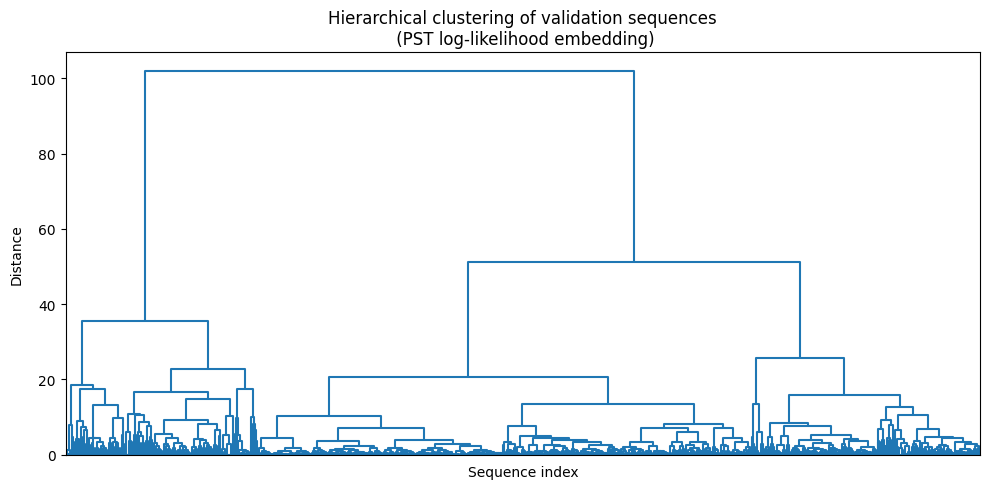

In [93]:
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
import matplotlib.pyplot as plt

Z_val = linkage(X_embed_val_z, method='ward')    # clustering

plt.figure(figsize=(10, 5))
dendrogram(
    Z_val,
    no_labels=True,      # too many points to label individually
    color_threshold=0.0
)
plt.title("Hierarchical clustering of validation sequences\n (PST log-likelihood embedding)")
plt.xlabel("Sequence index")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()

_To interpret a dendrogram:_
- The y-axis (distance) tells proximity to other sequences, eg. the smaller the distance, the closer the linked sequences are to each other

In [94]:
num_clusters = len(family_names)
clusters_val = fcluster(Z_val, t=num_clusters, criterion='maxclust')

print("Unique cluster IDs:", sorted(set(clusters_val)))
print("First 20 cluster IDs:", clusters_val[:20])

Unique cluster IDs: [1, 2, 3, 4, 5, 6, 7, 8]
First 20 cluster IDs: [6 5 6 5 8 5 2 8 5 6 5 8 5 5 8 5 5 6 8 5]


In [95]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

# external metrics
ARI_val = adjusted_rand_score(val_labels, clusters_val)
NMI_val = normalized_mutual_info_score(val_labels, clusters_val)

print("Validation ARI:", ARI_val)
print("Validation NMI:", NMI_val)

Validation ARI: 0.01590052793710121
Validation NMI: 0.054832191236195905


In [96]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# internal metrics
sil_score = silhouette_score(X_embed_val_z, clusters_val, metric="euclidean")
dbi_score = davies_bouldin_score(X_embed_val_z, clusters_val)
ch_score  = calinski_harabasz_score(X_embed_val_z, clusters_val)

print("Silhouette score:", sil_score)
print("DBI score:", dbi_score)
print("CH score:", ch_score)

Silhouette score: 0.20356348170531213
DBI score: 1.387346662293833
CH score: 494.2831719063189


In [97]:
import collections

def cluster_stats(clusters, labels):
    for cid in sorted(set(clusters)):
        idx = [i for i, c in enumerate(clusters) if c == cid]
        fams = [labels[i] for i in idx]
        counter = collections.Counter(fams)
        print(f"\nCluster {cid} (size {len(idx)}):")
        for fam, cnt in counter.most_common():
            print(f"  {fam}: {cnt}")

cluster_stats(clusters_val, val_labels)


Cluster 1 (size 13):
  Virus: 9
  Worms: 2
  Trojan: 1
  Spyware: 1

Cluster 2 (size 79):
  Virus: 27
  Worms: 13
  Trojan: 12
  Spyware: 9
  Backdoor: 8
  Downloader: 5
  Dropper: 5

Cluster 3 (size 172):
  Worms: 45
  Downloader: 29
  Virus: 29
  Trojan: 25
  Dropper: 17
  Backdoor: 15
  Spyware: 12

Cluster 4 (size 35):
  Virus: 20
  Spyware: 5
  Trojan: 4
  Worms: 4
  Backdoor: 1
  Dropper: 1

Cluster 5 (size 383):
  Downloader: 86
  Trojan: 63
  Backdoor: 59
  Dropper: 58
  Spyware: 46
  Worms: 28
  Adware: 24
  Virus: 19

Cluster 6 (size 388):
  Worms: 66
  Backdoor: 58
  Trojan: 57
  Downloader: 56
  Virus: 51
  Spyware: 48
  Dropper: 35
  Adware: 17

Cluster 7 (size 23):
  Backdoor: 9
  Worms: 7
  Trojan: 2
  Downloader: 2
  Spyware: 2
  Dropper: 1

Cluster 8 (size 334):
  Dropper: 62
  Backdoor: 51
  Virus: 46
  Spyware: 44
  Trojan: 37
  Worms: 36
  Adware: 35
  Downloader: 23


### Definition
Vector embeddings were length-normalized using ave-LL-per-symbol so each embeddings for unequal lengths will be comparable across the same scale. <br>
_Since PST log-likelihood decomposes as a sum over events, raw log-likelihood magnitude scales with trace length and can dominate distance-based clustering, causing clusters to reflect duration rather than behavioural structure. We therefore normalize log-likelihood by sequence length, yielding an average log-likelihood per event (cross-entropy rate) that provides a length-invariant measure of model fit. This improves comparability across samples and encourages clustering to reflect differences in probabilistic sequencing patterns rather than observation length._ <br>

**Silhouette Score**：evaluates how well a point fit in its own cluster compared to next nearest cluster from range [-1, 1], with a higher score implying compact clusters <br>

**Davies Bouldin Score**: measures ratio of within-cluster scatter to between-cluster separation from range [0, inf], (the lower the better) <br>

**Calinski Harabasz**: measures ratio of between-cluster dispersion to within-cluster dispersion from range [0, inf], (the higher the better) <br>

**ARI**: to evaluate how well a clustering algorithm's output matches true classification from range [-1, 1]
- Negative ARI value reveals that clustering into ground truth is less than expected if it was random, possibly implying a lack of signal relative to ground truth <br>

**NMI**: measures how much information two clusterings share from range [0, 1], for sequences i and j:
- If label_i = label_j, and cluster_i = cluster_j, high NMI
- If label_i != label_j, and cluster_i != cluster_j, high NMI
- Else, low NMI

### Visualization

In [98]:
import pandas as pd

clusters = np.asarray(clusters_val)
labels = np.asarray(val_labels)

# contingency table where rows = family, cols = cluster
ct = pd.crosstab(labels, clusters)

cluster_sizes = ct.sum(axis=0)  # size per cluster
family_totals = ct.sum(axis=1)  # total per family
N = int(cluster_sizes.sum())

print("N sequences:", N)
print("Families:", list(ct.index))
print("Clusters:", list(ct.columns))

N sequences: 1427
Families: ['Adware', 'Backdoor', 'Downloader', 'Dropper', 'Spyware', 'Trojan', 'Virus', 'Worms']
Clusters: [1, 2, 3, 4, 5, 6, 7, 8]


In [99]:
def cluster_purity_entropy(ct: pd.DataFrame) -> pd.DataFrame:
    cluster_sizes = ct.sum(axis=0)
    rows = []

    for c in ct.columns:
        col = ct[c]
        size = int(cluster_sizes[c])
        if size == 0:
            continue

        # proportions within cluster
        p = (col[col > 0] / size).astype(float)

        # entropy in bits
        entropy = float(-(p * np.log2(p)).sum())

        # majority label (purity)
        majority_family = str(col.idxmax())
        majority_count = int(col.max())
        purity = majority_count / size

        rows.append({
            "cluster": int(c),
            "size": size,
            "majority_family": majority_family,
            "majority_count": majority_count,
            "purity": purity,
            "entropy_bits": entropy,
            "num_families_present": int((col > 0).sum())
        })

    df = pd.DataFrame(rows).sort_values(["size", "purity"], ascending=[False, False]).reset_index(drop=True)
    return df

cluster_summary = cluster_purity_entropy(ct)
cluster_summary

,cluster,size,majority_family,majority_count,purity,entropy_bits,num_families_present
0,6,388,Worms,66,0.170103,2.922688,8
1,5,383,Downloader,86,0.224543,2.848810,8
2,8,334,Dropper,62,0.185629,2.949014,8
3,3,172,Worms,45,0.261628,2.681483,7
4,2,79,Virus,27,0.341772,2.566365,7
5,4,35,Virus,20,0.571429,1.870763,6
6,7,23,Backdoor,9,0.391304,2.167875,6
7,1,13,Virus,9,0.692308,1.352030,4


In [100]:
# counts table: how many samples from each family end up in each cluster -> answers whether a family spread across many clusters (heterogeneous), or concentrated (consistent behaviour)
family_cluster_counts = ct.copy()
family_cluster_counts

col_0,1,2,3,4,5,6,7,8
row_0,,,,,,,,
Adware,0,0,0,0,24,17,0,35
Backdoor,0,8,15,1,59,58,9,51
Downloader,0,5,29,0,86,56,2,23
Dropper,0,5,17,1,58,35,1,62
Spyware,1,9,12,5,46,48,2,44
Trojan,1,12,25,4,63,57,2,37
Virus,9,27,29,20,19,51,0,46
Worms,2,13,45,4,28,66,7,36


In [101]:
# row-normalized proportions: for each family, fraction that lands in each cluster
family_cluster_props = ct.div(ct.sum(axis=1), axis=0).fillna(0.0)
family_cluster_props

col_0,1,2,3,4,5,6,7,8
row_0,,,,,,,,
Adware,0.000000,0.000000,0.000000,0.000000,0.315789,0.223684,0.000000,0.460526
Backdoor,0.000000,0.039801,0.074627,0.004975,0.293532,0.288557,0.044776,0.253731
Downloader,0.000000,0.024876,0.144279,0.000000,0.427861,0.278607,0.009950,0.114428
Dropper,0.000000,0.027933,0.094972,0.005587,0.324022,0.195531,0.005587,0.346369
Spyware,0.005988,0.053892,0.071856,0.029940,0.275449,0.287425,0.011976,0.263473
Trojan,0.004975,0.059701,0.124378,0.019900,0.313433,0.283582,0.009950,0.184080
Virus,0.044776,0.134328,0.144279,0.099502,0.094527,0.253731,0.000000,0.228856
Worms,0.009950,0.064677,0.223881,0.019900,0.139303,0.328358,0.034826,0.179104


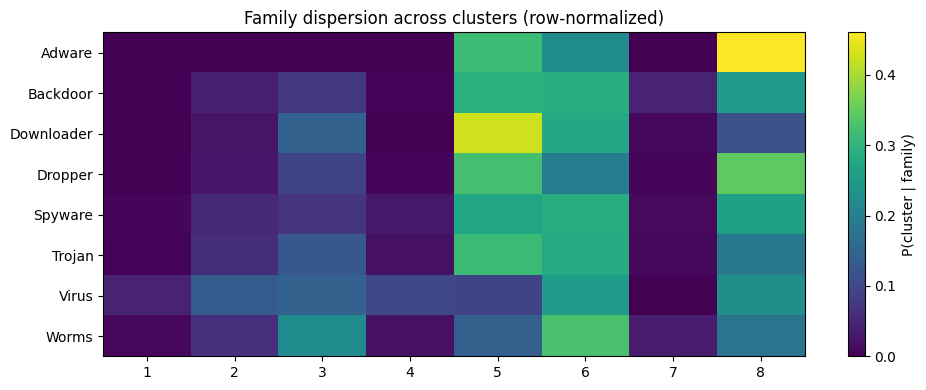

In [102]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.imshow(family_cluster_props.values, aspect='auto')
plt.yticks(range(len(family_cluster_props.index)), family_cluster_props.index)
plt.xticks(range(len(family_cluster_props.columns)), family_cluster_props.columns)
plt.colorbar(label="P(cluster | family)")
plt.title("Family dispersion across clusters (row-normalized)")
plt.tight_layout()
plt.show()

# if a family has one or two bright columns → “behaviourally consistent”
# if it’s spread across many columns → “behaviourally diverse / multi-modal”

In [103]:
# silhouette scores
from sklearn.metrics import silhouette_samples

def per_cluster_silhouette_stats(X, labels):
    X = np.asarray(X)
    labels = np.asarray(labels)

    # silhouette_samples gives a silhouette value for each point
    s = silhouette_samples(X, labels, metric="euclidean")

    stats = {}
    for c in np.unique(labels):
        idx = np.where(labels == c)[0]     # finds indices of points belonging to cluster c
        sc = s[idx]                        # takes silhouette values for those points in c
        stats[int(c)] = {
            "size": int(len(idx)),
            "mean": float(np.mean(sc)),
            "median": float(np.median(sc)),
            "min": float(np.min(sc)),
            "max": float(np.max(sc)),
            "q25": float(np.quantile(sc, 0.25)),
            "q75": float(np.quantile(sc, 0.75)),
        }

    return float(np.mean(s)), stats

global_sil, cluster_sil_stats = per_cluster_silhouette_stats(X_embed_val_z, clusters_val)

print("Global silhouette (from samples):", global_sil)
for c in sorted(cluster_sil_stats):
    st = cluster_sil_stats[c]
    print(f"Cluster {c}: size={st['size']}, mean={st['mean']:.4f}, "
          f"median={st['median']:.4f}, min={st['min']:.4f}, q25={st['q25']:.4f}, q75={st['q75']:.4f}, max={st['max']:.4f}")

Global silhouette (from samples): 0.20356348170531213
Cluster 1: size=13, mean=0.5799, median=0.6604, min=0.1898, q25=0.4593, q75=0.7038, max=0.7051
Cluster 2: size=79, mean=0.1096, median=0.1120, min=-0.2846, q25=0.0210, q75=0.2291, max=0.3795
Cluster 3: size=172, mean=0.0717, median=0.0848, min=-0.1969, q25=-0.0341, q75=0.1802, max=0.2791
Cluster 4: size=35, mean=0.2063, median=0.2498, min=-0.1168, q25=0.0636, q75=0.3609, max=0.3701
Cluster 5: size=383, mean=0.4504, median=0.4895, min=-0.0129, q25=0.4002, q75=0.5468, max=0.6088
Cluster 6: size=388, mean=0.0659, median=0.1119, min=-0.4970, q25=-0.0331, q75=0.1907, max=0.3243
Cluster 7: size=23, mean=0.3198, median=0.4256, min=-0.1906, q25=0.1580, q75=0.5280, max=0.5459
Cluster 8: size=334, mean=0.1475, median=0.1887, min=-0.3714, q25=0.0436, q75=0.2872, max=0.4121


In [104]:
# check to see proximity of smaller cluster centroids
def cluster_centroid_distances(X, labels, macro_cluster=None):
    X = np.asarray(X)
    labels = np.asarray(labels)

    clusters = np.unique(labels)

    # compute centroids + sizes
    centroids = {}
    sizes = {}
    for c in clusters:
        Xc = X[labels == c]
        centroids[int(c)] = Xc.mean(axis=0)
        sizes[int(c)] = int(Xc.shape[0])

    # pick macro cluster automatically if not provided
    if macro_cluster is None:
        macro_cluster = max(sizes, key=sizes.get)

    macro_mu = centroids[int(macro_cluster)]

    # compute distances
    rows = []
    for c in clusters:
        c = int(c)
        mu = centroids[c]
        dist_to_macro = float(np.linalg.norm(mu - macro_mu)) if c != int(macro_cluster) else 0.0

        # nearest other cluster centroid distance
        nearest_other = None
        nearest_other_dist = None
        for o in clusters:
            o = int(o)
            if o == c:
                continue
            d = float(np.linalg.norm(mu - centroids[o]))
            if nearest_other_dist is None or d < nearest_other_dist:
                nearest_other_dist = d
                nearest_other = o

        rows.append((c, sizes[c], dist_to_macro, nearest_other, nearest_other_dist))

    # sort: macro first, then by descending size
    rows.sort(key=lambda r: (r[0] != int(macro_cluster), -r[1]))
    return int(macro_cluster), rows

macro, rows = cluster_centroid_distances(X_embed_val_z, clusters_val)
print("Macro cluster (largest):", macro)
for c, sz, dmacro, near, dnear in rows:
    print(f"Cluster {c:>2} | size={sz:>4} | dist_to_macro={dmacro:>10.4f} | nearest={near:>2} (d={dnear:>8.4f})")

Macro cluster (largest): 6
Cluster  6 | size= 388 | dist_to_macro=    0.0000 | nearest= 5 (d=  1.0541)
Cluster  5 | size= 383 | dist_to_macro=    1.0541 | nearest= 6 (d=  1.0541)
Cluster  8 | size= 334 | dist_to_macro=    1.8854 | nearest= 6 (d=  1.8854)
Cluster  3 | size= 172 | dist_to_macro=    4.0323 | nearest= 8 (d=  2.2348)
Cluster  2 | size=  79 | dist_to_macro=    6.8752 | nearest= 3 (d=  3.0006)
Cluster  4 | size=  35 | dist_to_macro=    4.7810 | nearest= 3 (d=  2.9728)
Cluster  7 | size=  23 | dist_to_macro=    3.9971 | nearest= 8 (d=  3.9214)
Cluster  1 | size=  13 | dist_to_macro=    8.7091 | nearest= 2 (d=  3.8876)


## Clustering 2.0 (Shuffling of data, Retraining)
This is to generate reliability and stability of models (keep the tuned hyperparameters fixed and retrain the models)
- Retuning would instead test the stability of the tuning procedure and not the model
- Objective here is to see if given a chosen PST architecture (hyperparameters), does the learned behavioral structure persist under different data samples <br>

_Hyperparameters were selected once using classification-driven tuning on the original data split. To assess clustering stability, these hyperparameters were kept fixed across shuffled retraining runs to isolate the effect of sampling variation in the training set._
- This aims to examine whether PSTs learn approximately the same behavioral manifold, even if the training sequences change slightly **(yes = clusters reflect underlying behavior, no = clusters unreliable for analysis and obfuscating reasoning)**

In [105]:
# one shot extract all sequences belonging to each family
family_to_all_sequences = {fam: [] for fam in family_names}
for seq, label in zip(X_int, y):
    if label in family_to_all_sequences:
        family_to_all_sequences[label].append(seq)

# sanity check
for fam in family_names:
    print(f"Family {fam:9s} : n = {len(family_to_all_sequences[fam])}")

Family Trojan    : n = 1001
Family Backdoor  : n = 1001
Family Downloader : n = 1001
Family Worms     : n = 1001
Family Virus     : n = 1001
Family Dropper   : n = 891
Family Spyware   : n = 832
Family Adware    : n = 379


In [106]:
# build new PSTs for different runs with fixed hyperparams
def build_models_with_same_hyperparams(tuned_models):
    new_models = {}
    for fam, base_model in tuned_models.items():
        m = PSTModel(
            max_depth = base_model.max_depth,
            min_count = base_model.min_count,
            ymin      = base_model.ymin,
            gain_cutoff = base_model.gain_cutoff
        )
        new_models[fam] = m
    return new_models

# shuffling train test split per family (each rng is independent but can be reproducible across notebook runs)
def make_train_val_sets(family_to_all_sequences, family_names, rng):
    train_set = {}
    val_set   = {}

    for fam in family_names:
        seqs = family_to_all_sequences[fam]     # ensure each family gets proportionate training data
        seqs_shuffled = seqs[:]  
        rng.shuffle(seqs_shuffled) 

        split = int(0.8 * len(seqs_shuffled))
        train_set[fam] = seqs_shuffled[:split]
        val_set[fam]   = seqs_shuffled[split:]

    return train_set, val_set

# clustering and metrics for single run
def run_one_clustering_experiment(models, train_set, val_set, family_names):
    # fitting each family model
    for fam in family_names:
        seqs_train = train_set[fam]
        models[fam].fit(seqs_train)

    # union of all validation sets
    val_seqs  = []
    val_labels = []
    for fam in family_names:
        for s in val_set[fam]:
            val_seqs.append(s)
            val_labels.append(fam)

    X_embed_val = []
    for seq in val_seqs:
        vec = likelihood_vector_len_norm(seq, models, family_names)
        X_embed_val.append(vec)
    X_embed_val = np.vstack(X_embed_val)

    scaler = StandardScaler()
    X_embed_val_z = scaler.fit_transform(X_embed_val)

    Z_val = linkage(X_embed_val_z, method='ward')
    clusters_val = fcluster(Z_val, t=num_clusters, criterion='maxclust')

    # external metrics
    ARI_val = adjusted_rand_score(val_labels, clusters_val)
    NMI_val = normalized_mutual_info_score(val_labels, clusters_val)

    # internal metrics
    sil_score = silhouette_score(X_embed_val_z, clusters_val, metric="euclidean")
    dbi_score = davies_bouldin_score(X_embed_val_z, clusters_val)

    # visualization
    clusters = np.asarray(clusters_val)
    labels = np.asarray(val_labels)
    ct = pd.crosstab(labels, clusters)
    
    cluster_summary = cluster_purity_entropy(ct)
    print(cluster_summary)
    family_cluster_counts = ct.copy()
    family_cluster_props = ct.div(ct.sum(axis=1), axis=0).fillna(0.0)
    print(family_cluster_props)

    plt.figure(figsize=(10, 4))
    plt.imshow(family_cluster_props.values, aspect='auto')
    plt.yticks(range(len(family_cluster_props.index)), family_cluster_props.index)
    plt.xticks(range(len(family_cluster_props.columns)), family_cluster_props.columns)
    plt.colorbar(label="P(cluster | family)")
    plt.title("Family dispersion across clusters (row-normalized)")
    plt.tight_layout()
    plt.show()

    global_sil, cluster_sil_stats = per_cluster_silhouette_stats(X_embed_val_z, clusters_val)
    print("Global silhouette (from samples):", global_sil)
    for c in sorted(cluster_sil_stats):
        st = cluster_sil_stats[c]
        print(f"Cluster {c}: size={st['size']}, mean={st['mean']:.4f}, "
              f"median={st['median']:.4f}, min={st['min']:.4f}, q25={st['q25']:.4f}, q75={st['q75']:.4f}, max={st['max']:.4f}")

    macro, rows = cluster_centroid_distances(X_embed_val_z, clusters_val)
    print("Macro cluster (largest):", macro)
    for c, sz, dmacro, near, dnear in rows:
        print(f"Cluster {c:>2} | size={sz:>4} | dist_to_macro={dmacro:>10.4f} | nearest={near:>2} (d={dnear:>8.4f})")

    return ARI_val, NMI_val, sil_score, dbi_score, val_labels, clusters_val


=== Run 1/10 ===
   cluster  size majority_family  majority_count    purity  entropy_bits  \
0        1   435      Downloader             109  0.250575      2.799781   
1        2   401           Worms              73  0.182045      2.945405   
2        8   275         Dropper              49  0.178182      2.961883   
3        6   232           Virus              85  0.366379      2.543326   
4        5    31         Spyware               7  0.225806      2.512565   
5        3    25           Virus              20  0.800000      0.866314   
6        7    22        Backdoor              13  0.590909      1.288650   
7        4     6         Spyware               5  0.833333      0.650022   

   num_families_present  
0                     8  
1                     8  
2                     8  
3                     8  
4                     6  
5                     3  
6                     3  
7                     2  
col_0              1         2         3         4         5   

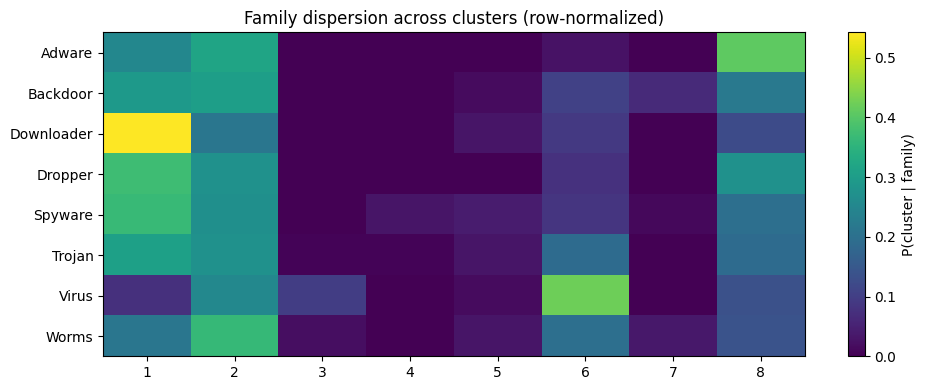

Global silhouette (from samples): 0.23759736213240806
Cluster 1: size=435, mean=0.4484, median=0.4994, min=-0.2568, q25=0.3618, q75=0.5657, max=0.6182
Cluster 2: size=401, mean=0.1874, median=0.2293, min=-0.3437, q25=0.0576, q75=0.3245, max=0.4370
Cluster 3: size=25, mean=0.5471, median=0.6834, min=0.0559, q25=0.3756, q75=0.7159, max=0.7185
Cluster 4: size=6, mean=0.2740, median=0.3275, min=-0.1171, q25=0.1249, q75=0.4950, max=0.4978
Cluster 5: size=31, mean=0.0736, median=0.1224, min=-0.3001, q25=-0.0024, q75=0.1649, max=0.2600
Cluster 6: size=232, mean=0.0256, median=0.0663, min=-0.4460, q25=-0.0957, q75=0.1570, max=0.3026
Cluster 7: size=22, mean=0.5231, median=0.6626, min=0.0713, q25=0.4495, q75=0.6881, max=0.7043
Cluster 8: size=275, mean=0.1230, median=0.1576, min=-0.3831, q25=0.0149, q75=0.2554, max=0.3919
Macro cluster (largest): 1
Cluster  1 | size= 435 | dist_to_macro=    0.0000 | nearest= 2 (d=  1.1073)
Cluster  2 | size= 401 | dist_to_macro=    1.1073 | nearest= 1 (d=  1.10

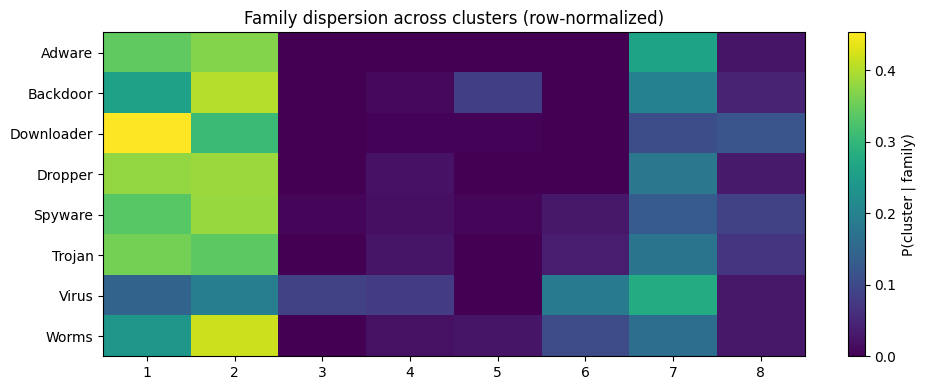

Global silhouette (from samples): 0.2756720796660559
Cluster 1: size=442, mean=0.5203, median=0.5711, min=-0.1068, q25=0.4637, q75=0.6188, max=0.6666
Cluster 2: size=495, mean=0.1477, median=0.1940, min=-0.4324, q25=0.0095, q75=0.3227, max=0.4596
Cluster 3: size=19, mean=0.6402, median=0.7678, min=0.2650, q25=0.4599, q75=0.7738, max=0.7771
Cluster 4: size=35, mean=0.1078, median=0.1180, min=-0.0891, q25=0.0329, q75=0.1800, max=0.3232
Cluster 5: size=24, mean=0.6234, median=0.6617, min=0.4345, q25=0.5219, q75=0.7260, max=0.7427
Cluster 6: size=70, mean=0.2026, median=0.1966, min=-0.3762, q25=0.0596, q75=0.3996, max=0.4226
Cluster 7: size=260, mean=0.1608, median=0.1648, min=-0.2490, q25=0.0541, q75=0.2828, max=0.4187
Cluster 8: size=82, mean=0.0417, median=0.0437, min=-0.2482, q25=-0.0410, q75=0.1305, max=0.2382
Macro cluster (largest): 2
Cluster  2 | size= 495 | dist_to_macro=    0.0000 | nearest= 1 (d=  1.4820)
Cluster  1 | size= 442 | dist_to_macro=    1.4820 | nearest= 2 (d=  1.4820

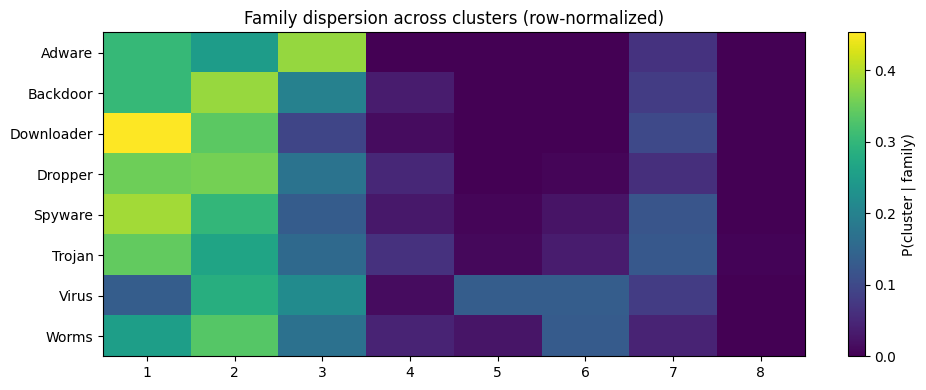

Global silhouette (from samples): 0.2609141674990417
Cluster 1: size=450, mean=0.5278, median=0.5686, min=0.1384, q25=0.4577, q75=0.6110, max=0.6681
Cluster 2: size=455, mean=0.1122, median=0.1404, min=-0.3762, q25=-0.0199, q75=0.2515, max=0.4163
Cluster 3: size=250, mean=0.2059, median=0.2278, min=-0.2929, q25=0.0872, q75=0.3392, max=0.4602
Cluster 4: size=49, mean=-0.1150, median=-0.1197, min=-0.4350, q25=-0.1931, q75=-0.0171, max=0.0668
Cluster 5: size=35, mean=0.3343, median=0.3876, min=-0.0519, q25=0.1799, q75=0.5439, max=0.5507
Cluster 6: size=65, mean=0.1823, median=0.1972, min=-0.1677, q25=0.0753, q75=0.3656, max=0.3814
Cluster 7: size=122, mean=0.1178, median=0.1405, min=-0.2438, q25=0.0204, q75=0.2215, max=0.3991
Cluster 8: size=1, mean=0.0000, median=0.0000, min=0.0000, q25=0.0000, q75=0.0000, max=0.0000
Macro cluster (largest): 2
Cluster  2 | size= 455 | dist_to_macro=    0.0000 | nearest= 1 (d=  1.3842)
Cluster  1 | size= 450 | dist_to_macro=    1.3842 | nearest= 2 (d=  1.

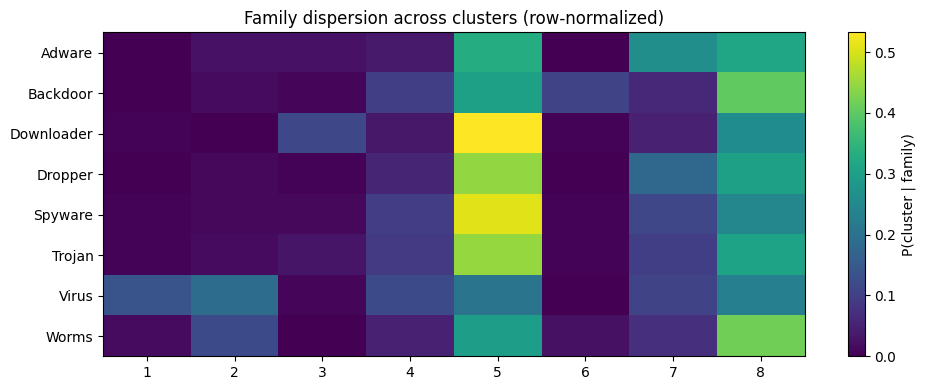

Global silhouette (from samples): 0.27472420556026567
Cluster 1: size=34, mean=0.2694, median=0.3791, min=-0.3081, q25=0.1221, q75=0.5075, max=0.5212
Cluster 2: size=74, mean=0.1482, median=0.1461, min=-0.3892, q25=0.0354, q75=0.3710, max=0.3801
Cluster 3: size=38, mean=0.0840, median=0.1592, min=-0.5575, q25=0.0170, q75=0.1950, max=0.3179
Cluster 4: size=108, mean=-0.0131, median=0.0031, min=-0.4258, q25=-0.1088, q75=0.0880, max=0.2433
Cluster 5: size=549, mean=0.5308, median=0.5789, min=0.0471, q25=0.4662, q75=0.6237, max=0.6740
Cluster 6: size=30, mean=0.3736, median=0.4800, min=-0.3058, q25=0.3027, q75=0.5787, max=0.5966
Cluster 7: size=150, mean=0.2980, median=0.3214, min=-0.0453, q25=0.2214, q75=0.3994, max=0.5076
Cluster 8: size=444, mean=0.0513, median=0.0751, min=-0.4224, q25=-0.0627, q75=0.1875, max=0.3266
Macro cluster (largest): 5
Cluster  5 | size= 549 | dist_to_macro=    0.0000 | nearest= 8 (d=  1.5776)
Cluster  8 | size= 444 | dist_to_macro=    1.5776 | nearest= 5 (d=  1

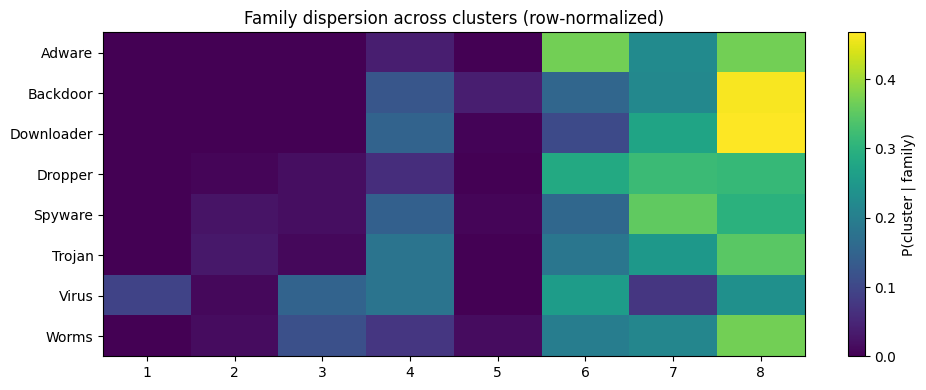

Global silhouette (from samples): 0.23272121539988927
Cluster 1: size=19, mean=0.7339, median=0.7981, min=0.5245, q25=0.6733, q75=0.8111, max=0.8147
Cluster 2: size=16, mean=0.2189, median=0.2253, min=-0.1206, q25=0.2008, q75=0.2748, max=0.3894
Cluster 3: size=61, mean=0.1499, median=0.1803, min=-0.3392, q25=0.0513, q75=0.3295, max=0.3528
Cluster 4: size=180, mean=0.0420, median=0.0756, min=-0.4282, q25=-0.1126, q75=0.1909, max=0.3538
Cluster 5: size=13, mean=0.6656, median=0.7660, min=0.4241, q25=0.4980, q75=0.7703, max=0.7853
Cluster 6: size=286, mean=0.1972, median=0.2395, min=-0.2888, q25=0.0830, q75=0.3325, max=0.4542
Cluster 7: size=340, mean=0.5449, median=0.5715, min=0.0687, q25=0.4943, q75=0.6252, max=0.6799
Cluster 8: size=512, mean=0.0930, median=0.1356, min=-0.5178, q25=-0.0453, q75=0.2718, max=0.3994
Macro cluster (largest): 8
Cluster  8 | size= 512 | dist_to_macro=    0.0000 | nearest= 7 (d=  1.2453)
Cluster  7 | size= 340 | dist_to_macro=    1.2453 | nearest= 8 (d=  1.24

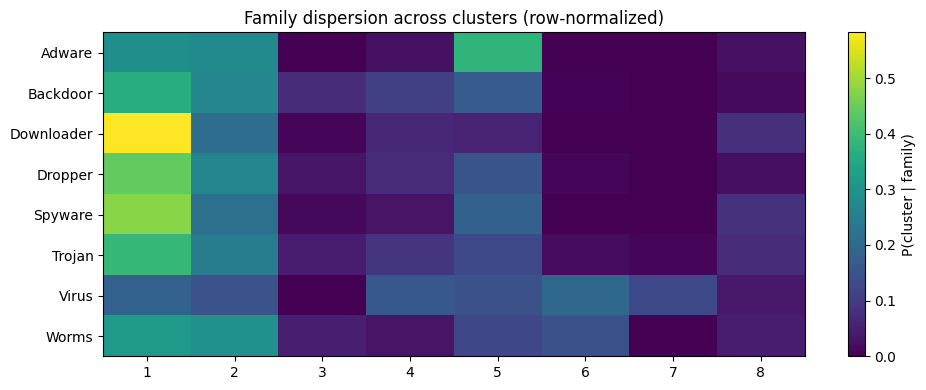

Global silhouette (from samples): 0.24863997856916004
Cluster 1: size=549, mean=0.4501, median=0.5087, min=-0.2674, q25=0.3759, q75=0.5652, max=0.6207
Cluster 2: size=339, mean=0.1728, median=0.2113, min=-0.3290, q25=0.0781, q75=0.2842, max=0.4146
Cluster 3: size=44, mean=0.0291, median=0.0639, min=-0.3495, q25=-0.1213, q75=0.1323, max=0.3334
Cluster 4: size=111, mean=0.2134, median=0.2361, min=-0.1670, q25=0.1284, q75=0.3125, max=0.4076
Cluster 5: size=210, mean=-0.0054, median=0.0122, min=-0.4591, q25=-0.0693, q75=0.1054, max=0.1937
Cluster 6: size=75, mean=0.1945, median=0.2140, min=-0.3256, q25=0.0190, q75=0.4343, max=0.4490
Cluster 7: size=28, mean=0.3581, median=0.4759, min=-0.0812, q25=0.2000, q75=0.5514, max=0.5602
Cluster 8: size=71, mean=0.0101, median=0.0196, min=-0.4194, q25=-0.0993, q75=0.1638, max=0.3121
Macro cluster (largest): 1
Cluster  1 | size= 549 | dist_to_macro=    0.0000 | nearest= 2 (d=  1.4275)
Cluster  2 | size= 339 | dist_to_macro=    1.4275 | nearest= 5 (d= 

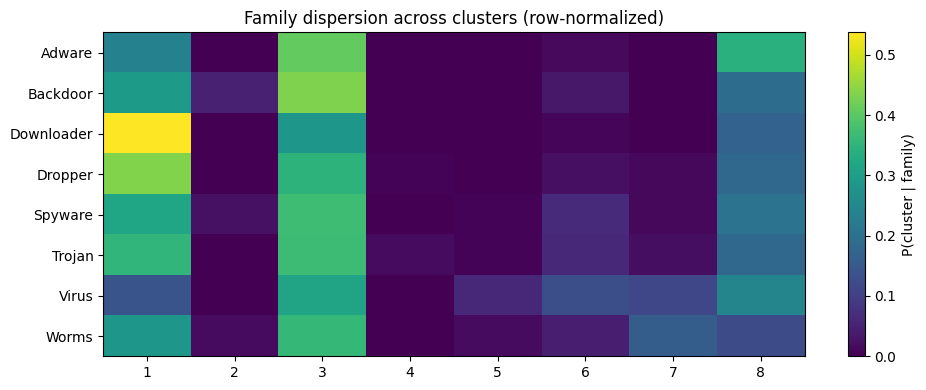

Global silhouette (from samples): 0.27695416214485324
Cluster 1: size=472, mean=0.5524, median=0.5965, min=0.0101, q25=0.4933, q75=0.6429, max=0.6879
Cluster 2: size=17, mean=0.7487, median=0.8324, min=0.1762, q25=0.7274, q75=0.8416, max=0.8525
Cluster 3: size=508, mean=0.1184, median=0.1856, min=-0.5240, q25=-0.0393, q75=0.2984, max=0.4323
Cluster 4: size=4, mean=0.3675, median=0.3685, min=0.3516, q25=0.3568, q75=0.3792, max=0.3816
Cluster 5: size=17, mean=0.3579, median=0.3121, min=0.1374, q25=0.2490, q75=0.4857, max=0.5270
Cluster 6: size=72, mean=0.1932, median=0.2117, min=-0.2026, q25=0.1059, q75=0.3081, max=0.4413
Cluster 7: size=63, mean=0.2399, median=0.2547, min=-0.2005, q25=0.1361, q75=0.4110, max=0.4257
Cluster 8: size=274, mean=0.0912, median=0.1046, min=-0.4091, q25=-0.0264, q75=0.2384, max=0.3807
Macro cluster (largest): 3
Cluster  3 | size= 508 | dist_to_macro=    0.0000 | nearest= 1 (d=  1.6071)
Cluster  1 | size= 472 | dist_to_macro=    1.6071 | nearest= 3 (d=  1.6071)

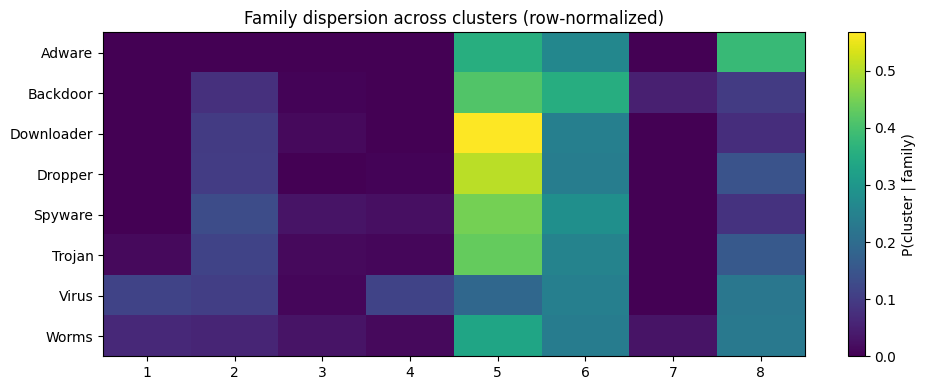

Global silhouette (from samples): 0.2850424568804879
Cluster 1: size=39, mean=0.4586, median=0.5734, min=0.0940, q25=0.3432, q75=0.5895, max=0.5994
Cluster 2: size=132, mean=0.1730, median=0.2024, min=-0.1631, q25=0.0435, q75=0.2992, max=0.4339
Cluster 3: size=20, mean=0.0801, median=0.0841, min=-0.1451, q25=-0.0424, q75=0.1883, max=0.3058
Cluster 4: size=33, mean=0.2395, median=0.3204, min=-0.4118, q25=0.1678, q75=0.3452, max=0.4428
Cluster 5: size=582, mean=0.4806, median=0.5435, min=-0.1326, q25=0.3975, q75=0.5949, max=0.6455
Cluster 6: size=378, mean=0.1724, median=0.2291, min=-0.4259, q25=0.0597, q75=0.3099, max=0.4393
Cluster 7: size=16, mean=0.5412, median=0.6691, min=0.0796, q25=0.3596, q75=0.6840, max=0.6929
Cluster 8: size=227, mean=0.0132, median=0.0188, min=-0.3930, q25=-0.0897, q75=0.1336, max=0.2793
Macro cluster (largest): 5
Cluster  5 | size= 582 | dist_to_macro=    0.0000 | nearest= 6 (d=  1.5013)
Cluster  6 | size= 378 | dist_to_macro=    1.5013 | nearest= 5 (d=  1.50

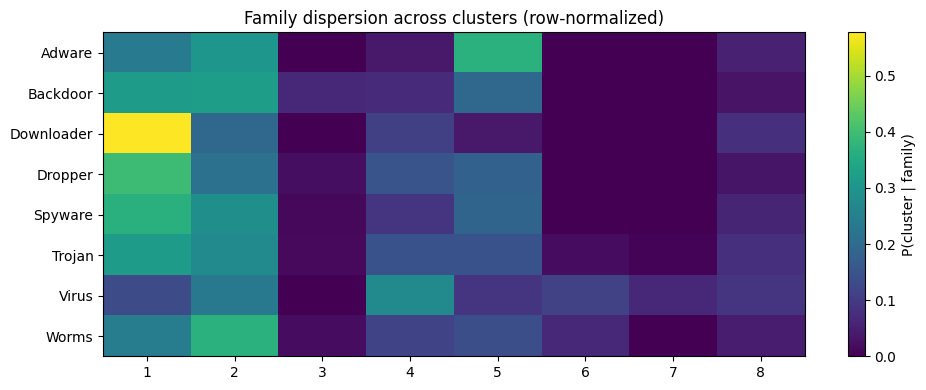

Global silhouette (from samples): 0.24108079621446754
Cluster 1: size=470, mean=0.4581, median=0.5106, min=-0.1665, q25=0.3882, q75=0.5592, max=0.6176
Cluster 2: size=390, mean=0.1651, median=0.2166, min=-0.3687, q25=0.0381, q75=0.3157, max=0.4416
Cluster 3: size=26, mean=0.1840, median=0.1520, min=-0.0348, q25=0.0982, q75=0.3097, max=0.3717
Cluster 4: size=189, mean=0.1391, median=0.1603, min=-0.2812, q25=0.0371, q75=0.2396, max=0.3691
Cluster 5: size=213, mean=0.0451, median=0.0507, min=-0.2635, q25=-0.0174, q75=0.1224, max=0.2409
Cluster 6: size=40, mean=0.3280, median=0.3985, min=-0.0963, q25=0.1731, q75=0.4916, max=0.5016
Cluster 7: size=14, mean=0.7175, median=0.8174, min=0.4201, q25=0.5952, q75=0.8211, max=0.8237
Cluster 8: size=85, mean=0.0054, median=0.0251, min=-0.3332, q25=-0.1351, q75=0.1178, max=0.2970
Macro cluster (largest): 1
Cluster  1 | size= 470 | dist_to_macro=    0.0000 | nearest= 2 (d=  1.2552)
Cluster  2 | size= 390 | dist_to_macro=    1.2552 | nearest= 1 (d=  1.

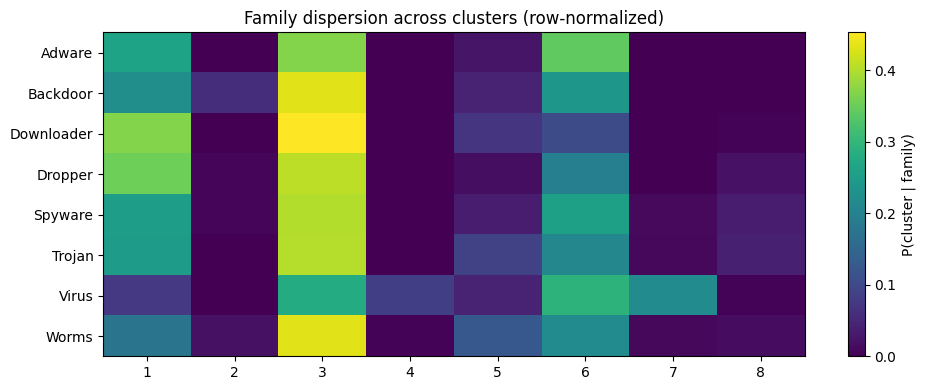

Global silhouette (from samples): 0.2540094325903004
Cluster 1: size=344, mean=0.5690, median=0.5989, min=0.0654, q25=0.5211, q75=0.6388, max=0.6875
Cluster 2: size=18, mean=0.7550, median=0.8092, min=0.3854, q25=0.7126, q75=0.8334, max=0.8415
Cluster 3: size=570, mean=0.1149, median=0.1872, min=-0.5160, q25=-0.0774, q75=0.3087, max=0.4276
Cluster 4: size=18, mean=0.5252, median=0.5451, min=0.1058, q25=0.4968, q75=0.6489, max=0.6548
Cluster 5: size=86, mean=0.0859, median=0.1197, min=-0.3978, q25=0.0011, q75=0.1889, max=0.3377
Cluster 6: size=318, mean=0.1646, median=0.1851, min=-0.3717, q25=0.0447, q75=0.3270, max=0.4703
Cluster 7: size=50, mean=0.3938, median=0.5652, min=-0.1805, q25=0.1978, q75=0.5806, max=0.5906
Cluster 8: size=23, mean=-0.0522, median=-0.0556, min=-0.4137, q25=-0.1279, q75=0.1047, max=0.1453
Macro cluster (largest): 3
Cluster  3 | size= 570 | dist_to_macro=    0.0000 | nearest= 1 (d=  1.3844)
Cluster  1 | size= 344 | dist_to_macro=    1.3844 | nearest= 3 (d=  1.38

In [107]:
# running K diff runs
K = 10
BASE_SEED = 100 # initial run used 42 so do not re-use

ari_list = []
nmi_list = []
sil_list = []
dbi_list = []

all_run_cluster_summaries = []

for run_idx in range(K):
    print(f"\n=== Run {run_idx+1}/{K} ===")
    
    rng = random.Random(BASE_SEED + run_idx)

    train_set, val_set = make_train_val_sets(family_to_all_sequences, family_names, rng)
    run_models = build_models_with_same_hyperparams(tuned_models)

    ARI_val, NMI_val, sil_score, dbi_score, val_labels_run, clusters_val_run = run_one_clustering_experiment( \
                                                                                run_models, train_set, val_set, family_names)

    ari_list.append(ARI_val)
    nmi_list.append(NMI_val)
    sil_list.append(sil_score)
    dbi_list.append(dbi_score)

    # cluster stats for each run
    cluster_stats(clusters_val_run, val_labels_run)

    print(f"ARI: {ARI_val:.6f}, NMI: {NMI_val:.6f}, Silhouette score: {sil_score:.6f}, DB score: {dbi_score:.6f}")

In [108]:
# evaluate mean and SD of ARI, NMI across runs to determine stability
print("ARI mean ± SD:", np.mean(ari_list), np.std(ari_list))
print("NMI mean ± SD:", np.mean(nmi_list), np.std(nmi_list))

ARI mean ± SD: 0.018475489708435062 0.005244313897289659
NMI mean ± SD: 0.07114860500883861 0.008091352134174886


### Interpretation and Analysis (multiple shuffling, retraining, and clustering)
**Objective of study**: Examine an alternative tree structure that incorporates probabilistic sequencing for clustering malware samples <br>
_Clustering accuracy using PSTs will be evaluated, and the key significance of this study lies in **improving behaviour-based clustering robustness under obfuscation**._

- Clustering accuracy (label-based/taxonomic alignment): ARI, NMI, cluster purity per family (existing) <br>
_Addresses 'Clustering accuracy using PSTs will be evaluated'._ <br>

- Behaviour-based clustering quality (generative structure): clustering purity per family, silhouette score -> shows how distinct each clusters are -> PST-based embeddings induce a stable clustering structure with one large, mixed behavioural core and several smaller, family-biased subclusters corresponding to specialised behaviours (e.g., propagation). This structure is robust across 10 randomized train/validation splits<br>
_Addresses 'Examine an alternative tree structure that incorporates probabilistic sequencing for clustering malware samples'._ <br>

**To address improving behaviour-based clustering robustness under obfuscation:**
- Synthetic obfuscation (simple obfuscation due to the difficulty in obtaining obfuscated datasets)
- Though synthetic obfuscation is simpler, this helps simulate realistic variations -> we will be comparing cluster purity per family
- PST models used are those trained on initial dataset to test robustness

## Clustering 3.0 (Synthetic Obfuscation)
The following tests the research objective (robustness under obfuscation)
- Keeping trained model and fixed hyperparameters, then clustering under obfuscated datasets aims the examine the inherent nature of the alternative tree structure, which is PSTs -> shows us whether probabilistic sequencing can allow it to maintain observed behavioural structure even under obfuscation
- Testing clustering on varying levels of obfuscation

In [ ]:
# adding random useless calls into a sequence
def insert_noise(seq, noise_rate=0.05):
    noisy_seq = seq[:]
    num_noisy_calls = int(len(seq) * noise_rate)
    for _ in range(num_noisy_calls):
        insert_pos = random.randint(0, len(noisy_seq))  # random position
        noisy_seq.insert(insert_pos, 278)  # 278 represents encoded dummy call
    return noisy_seq

# simulate control flow obfuscation
def shuffle_subsequence(seq, shuffle_rate=0.05):
    noisy_seq = seq[:]
    num_shuffles = int(len(seq) * shuffle_rate)
    for _ in range(num_shuffles):
        start_idx = random.randint(0, len(noisy_seq) - 2)
        end_idx = random.randint(start_idx + 1, len(noisy_seq))
        noi 
    return noisy_seq

# example for sanity check
original_sequence = X_int[0]

obfuscated_sequence_noise = insert_noise(original_sequence, noise_rate=0.2)
obfuscated_sequence_shuffle = shuffle_subsequence(original_sequence, shuffle_rate=0.2)

print("Original sequence:", original_sequence)
print("Obfuscated with noise:", obfuscated_sequence_noise)
print("Obfuscated with shuffle:", obfuscated_sequence_shuffle)

Original sequence: [0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 2, 3, 4, 5, 3, 4, 5, 6, 7, 8, 7, 9, 1, 9, 1, 0, 1, 10, 11, 12, 13, 14, 15, 16, 5, 17, 18, 5, 10, 3, 4, 5, 18]
Obfuscated with noise: [0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 278, 0, 278, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 278, 1, 2, 3, 278, 278, 278, 4, 5, 3, 4, 5, 6, 7, 8, 7, 9, 1, 9, 1, 278, 0, 1, 278, 278, 10, 11, 12, 278, 13, 14, 15, 16, 5, 17, 18, 5, 10, 3, 4, 278, 5, 18]
Obfuscated with shuffle: [0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 5, 0, 0, 9, 0, 0, 1, 5, 8, 4, 1, 11, 0, 1, 7, 1, 10, 3, 16, 4, 5, 15, 2, 0, 5, 17, 7, 4, 9, 0, 1, 0, 14, 10, 1, 18, 1, 3, 1, 6, 3, 18, 5, 13, 12, 0, 1]


In [112]:
# randomly select one obfuscation method for single sequence
def random_obfuscation(seq, noise_rate=0.2, shuffle_rate=0.2):
    method = random.choice(["shuffle", "insert_noise"])
    if method == "shuffle":
        return shuffle_subsequence(seq, shuffle_rate)
    else:
        return insert_noise(seq, noise_rate)

In [119]:
# obfuscation of all sequences
obfuscated_sequences = []
count = 1

for seq in X_int:
    print("Obfuscating seq" + str(count) + ", size: ", len(seq))
    obfuscated_sequence = random_obfuscation(seq, noise_rate=0.2, shuffle_rate=0.2)
    obfuscated_sequences.append(obfuscated_sequence)
    print("Obfuscating seq" + str(count))
    count+=1

Obfuscating seq1, size:  57
Obfuscating seq1
Obfuscating seq2, size:  208
Obfuscating seq2
Obfuscating seq3, size:  46
Obfuscating seq3
Obfuscating seq4, size:  291
Obfuscating seq4
Obfuscating seq5, size:  82
Obfuscating seq5
Obfuscating seq6, size:  34
Obfuscating seq6
Obfuscating seq7, size:  4311
Obfuscating seq7
Obfuscating seq8, size:  42
Obfuscating seq8
Obfuscating seq9, size:  277
Obfuscating seq9
Obfuscating seq10, size:  6395
Obfuscating seq10
Obfuscating seq11, size:  2131
Obfuscating seq11
Obfuscating seq12, size:  1124
Obfuscating seq12
Obfuscating seq13, size:  182
Obfuscating seq13
Obfuscating seq14, size:  300
Obfuscating seq14
Obfuscating seq15, size:  109
Obfuscating seq15
Obfuscating seq16, size:  111
Obfuscating seq16
Obfuscating seq17, size:  180
Obfuscating seq17
Obfuscating seq18, size:  312
Obfuscating seq18
Obfuscating seq19, size:  386
Obfuscating seq19
Obfuscating seq20, size:  113
Obfuscating seq20
Obfuscating seq21, size:  1573
Obfuscating seq21
Obfuscatin

In [122]:
with open("obfuscated_sequences.json", "w") as f:
    json.dump({"X_int": obfuscated_sequences, "y": y}, f)

print("Saved to obfuscated_sequences.json")

Saved to obfuscated_sequences.json


In [140]:
obfuscated_Xy = json.load(open("obfuscated_sequences.json"))
obfuscated_X_int = obfuscated_Xy["X_int"]
obfuscated_y = obfuscated_Xy["y"]

In [141]:
# one shot extract all sequences belonging to each family
family_to_all_obfuscated_sequences = {fam: [] for fam in family_names}
for seq, label in zip(obfuscated_X_int, obfuscated_y):
    if label in family_to_all_obfuscated_sequences:
        family_to_all_obfuscated_sequences[label].append(seq)

# sanity check
for fam in family_names:
    print(f"Family {fam:9s} : n = {len(family_to_all_obfuscated_sequences[fam])}")

Family Trojan    : n = 1001
Family Backdoor  : n = 1001
Family Downloader : n = 1001
Family Worms     : n = 1001
Family Virus     : n = 1001
Family Dropper   : n = 891
Family Spyware   : n = 832
Family Adware    : n = 379


In [114]:
# tuned models are trained on 'clean' sets, family_to_all_obfuscated_sequences is a dict of fam:sequences mapping
def run_one_obfuscated_clustering_experiment(tuned_models, family_names, family_to_all_obfuscated_sequences):
    # union of validation sets - in this case the whole obfuscated dataset
    val_seqs  = []
    val_labels = []
    for fam in family_names:
        for s in family_to_all_obfuscated_sequences[fam]:
            val_seqs.append(s)
            val_labels.append(fam)

    # embedding vector of all obfuscated sequences
    X_embed_val = []
    for seq in val_seqs:
        vec = likelihood_vector_len_norm(seq, tuned_models, family_names)
        X_embed_val.append(vec)
    X_embed_val = np.vstack(X_embed_val)

    scaler = StandardScaler()
    X_embed_val_z = scaler.fit_transform(X_embed_val)

    Z_val = linkage(X_embed_val_z, method='ward')
    clusters_val = fcluster(Z_val, t=num_clusters, criterion='maxclust')

    # external metrics
    ARI_val = adjusted_rand_score(val_labels, clusters_val)
    NMI_val = normalized_mutual_info_score(val_labels, clusters_val)

    # internal metrics
    sil_score = silhouette_score(X_embed_val_z, clusters_val, metric="euclidean")
    dbi_score = davies_bouldin_score(X_embed_val_z, clusters_val)

    # visualization
    clusters = np.asarray(clusters_val)
    labels = np.asarray(val_labels)
    ct = pd.crosstab(labels, clusters)

    cluster_summary = cluster_purity_entropy(ct)
    print(cluster_summary)
    family_cluster_counts = ct.copy()
    family_cluster_props = ct.div(ct.sum(axis=1), axis=0).fillna(0.0)
    print(family_cluster_props)

    plt.figure(figsize=(10, 4))
    plt.imshow(family_cluster_props.values, aspect='auto')
    plt.yticks(range(len(family_cluster_props.index)), family_cluster_props.index)
    plt.xticks(range(len(family_cluster_props.columns)), family_cluster_props.columns)
    plt.colorbar(label="P(cluster | family)")
    plt.title("Family dispersion across clusters (row-normalized)")
    plt.tight_layout()
    plt.show()

    global_sil, cluster_sil_stats = per_cluster_silhouette_stats(X_embed_val_z, clusters_val)
    print("Global silhouette (from samples):", global_sil)
    for c in sorted(cluster_sil_stats):
        st = cluster_sil_stats[c]
        print(f"Cluster {c}: size={st['size']}, mean={st['mean']:.4f}, "
              f"median={st['median']:.4f}, min={st['min']:.4f}, q25={st['q25']:.4f}, q75={st['q75']:.4f}, max={st['max']:.4f}")
    
    macro, rows = cluster_centroid_distances(X_embed_val_z, clusters_val)
    print("Macro cluster (largest):", macro)
    for c, sz, dmacro, near, dnear in rows:
        print(f"Cluster {c:>2} | size={sz:>4} | dist_to_macro={dmacro:>10.4f} | nearest={near:>2} (d={dnear:>8.4f})")

    return ARI_val, NMI_val, sil_score, dbi_score, val_labels, clusters_val


=== Run 1: noise_rate=0.2 ===
   cluster  size majority_family  majority_count    purity  entropy_bits  \
0        2  2596      Downloader             428  0.164869      2.930409   
1        4  2244           Virus             350  0.155971      2.970304   
2        3  1405      Downloader             235  0.167260      2.915997   
3        7   211           Virus             100  0.473934      1.357920   
4        1   209         Dropper              38  0.181818      2.948930   
5        5   205           Virus              97  0.473171      2.154884   
6        8   129         Spyware              91  0.705426      1.454811   
7        6   108        Backdoor              61  0.564815      1.804883   

   num_families_present  
0                     8  
1                     8  
2                     8  
3                     6  
4                     8  
5                     7  
6                     6  
7                     7  
col_0              1         2         3         4

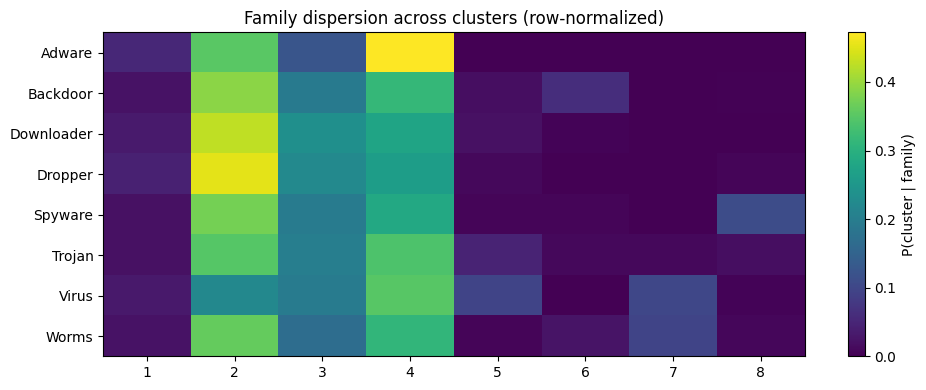

Global silhouette (from samples): 0.2022632654902306
Cluster 1: size=209, mean=0.3716, median=0.4211, min=-0.2045, q25=0.2581, q75=0.5230, max=0.5768
Cluster 2: size=2596, mean=0.2117, median=0.2796, min=-0.4738, q25=0.0411, q75=0.4233, max=0.4977
Cluster 3: size=1405, mean=0.3912, median=0.4110, min=-0.1017, q25=0.3197, q75=0.4929, max=0.5915
Cluster 4: size=2244, mean=0.1003, median=0.1449, min=-0.4501, q25=-0.0567, q75=0.2819, max=0.3848
Cluster 5: size=205, mean=0.0008, median=0.0382, min=-0.4206, q25=-0.1487, q75=0.1368, max=0.2748
Cluster 6: size=108, mean=0.1158, median=0.1246, min=-0.3173, q25=-0.0865, q75=0.3635, max=0.4352
Cluster 7: size=211, mean=0.1743, median=0.2055, min=-0.3976, q25=0.0506, q75=0.3627, max=0.3870
Cluster 8: size=129, mean=-0.1080, median=-0.0669, min=-0.5057, q25=-0.2730, q75=0.0650, max=0.1785
Macro cluster (largest): 2
Cluster  2 | size=2596 | dist_to_macro=    0.0000 | nearest= 3 (d=  1.6350)
Cluster  4 | size=2244 | dist_to_macro=    3.1233 | nearest

In [115]:
# no need for multiple runs - just testing for varying levels of obfuscation
print(f"\n=== Run 1: noise_rate=0.2 ===")

# no training involved, obfuscated sets used as validation
ARI_val, NMI_val, sil_score, dbi_score, val_labels_run, clusters_val_run = run_one_obfuscated_clustering_experiment( \
                                                                         tuned_models, family_names, family_to_all_obfuscated_sequences)
# cluster stats for each run
cluster_stats(clusters_val_run, val_labels_run)

print(f"ARI: {ARI_val:.6f}, NMI: {NMI_val:.6f}, Silhouette score: {sil_score:.6f}, DB score: {dbi_score:.6f}")

## Clustering 4.0 (Synthetic Obfuscation)
Varied level of obfuscation (slightly lesser)
- Objective: test robustness under different levels of obfuscation (noise rate=0.01, 0.05, 0.1)

In [113]:
# obfuscating on different levels - 0.01
obfuscated_sequences_point_01 = []
count = 1

for seq in X_int:
    print("Obfuscating seq" + str(count) + ", size: ", len(seq))
    obfuscated_sequence = random_obfuscation(seq, noise_rate=0.01, shuffle_rate=0.01)
    obfuscated_sequences_point_01.append(obfuscated_sequence)
    print("Obfuscating seq" + str(count))
    count+=1

Obfuscating seq1, size:  57
Obfuscating seq1
Obfuscating seq2, size:  208
Obfuscating seq2
Obfuscating seq3, size:  46
Obfuscating seq3
Obfuscating seq4, size:  291
Obfuscating seq4
Obfuscating seq5, size:  82
Obfuscating seq5
Obfuscating seq6, size:  34
Obfuscating seq6
Obfuscating seq7, size:  4311
Obfuscating seq7
Obfuscating seq8, size:  42
Obfuscating seq8
Obfuscating seq9, size:  277
Obfuscating seq9
Obfuscating seq10, size:  6395
Obfuscating seq10
Obfuscating seq11, size:  2131
Obfuscating seq11
Obfuscating seq12, size:  1124
Obfuscating seq12
Obfuscating seq13, size:  182
Obfuscating seq13
Obfuscating seq14, size:  300
Obfuscating seq14
Obfuscating seq15, size:  109
Obfuscating seq15
Obfuscating seq16, size:  111
Obfuscating seq16
Obfuscating seq17, size:  180
Obfuscating seq17
Obfuscating seq18, size:  312
Obfuscating seq18
Obfuscating seq19, size:  386
Obfuscating seq19
Obfuscating seq20, size:  113
Obfuscating seq20
Obfuscating seq21, size:  1573
Obfuscating seq21
Obfuscatin

In [114]:
with open("obfuscated_sequences_point_01.json", "w") as f:
    json.dump({"X_int": obfuscated_sequences_point_01, "y": y}, f)

print("Saved to obfuscated_sequences_point_01.json")

Saved to obfuscated_sequences_point_01.json


In [115]:
# obfuscating on different levels - 0.05
obfuscated_sequences_point_05 = []
count = 1

for seq in X_int:
    print("Obfuscating seq" + str(count) + ", size: ", len(seq))
    obfuscated_sequence = random_obfuscation(seq, noise_rate=0.05, shuffle_rate=0.05)
    obfuscated_sequences_point_05.append(obfuscated_sequence)
    print("Obfuscating seq" + str(count))
    count+=1

Obfuscating seq1, size:  57
Obfuscating seq1
Obfuscating seq2, size:  208
Obfuscating seq2
Obfuscating seq3, size:  46
Obfuscating seq3
Obfuscating seq4, size:  291
Obfuscating seq4
Obfuscating seq5, size:  82
Obfuscating seq5
Obfuscating seq6, size:  34
Obfuscating seq6
Obfuscating seq7, size:  4311
Obfuscating seq7
Obfuscating seq8, size:  42
Obfuscating seq8
Obfuscating seq9, size:  277
Obfuscating seq9
Obfuscating seq10, size:  6395
Obfuscating seq10
Obfuscating seq11, size:  2131
Obfuscating seq11
Obfuscating seq12, size:  1124
Obfuscating seq12
Obfuscating seq13, size:  182
Obfuscating seq13
Obfuscating seq14, size:  300
Obfuscating seq14
Obfuscating seq15, size:  109
Obfuscating seq15
Obfuscating seq16, size:  111
Obfuscating seq16
Obfuscating seq17, size:  180
Obfuscating seq17
Obfuscating seq18, size:  312
Obfuscating seq18
Obfuscating seq19, size:  386
Obfuscating seq19
Obfuscating seq20, size:  113
Obfuscating seq20
Obfuscating seq21, size:  1573
Obfuscating seq21
Obfuscatin

In [116]:
with open("obfuscated_sequences_point_05.json", "w") as f:
    json.dump({"X_int": obfuscated_sequences_point_05, "y": y}, f)

print("Saved to obfuscated_sequences_point_05.json")

Saved to obfuscated_sequences_point_05.json


In [118]:
# obfuscating on different levels - 0.1
obfuscated_sequences_point_1 = []
count = 1

for seq in X_int:
    print("Obfuscating seq" + str(count) + ", size: ", len(seq))
    obfuscated_sequence = random_obfuscation(seq, noise_rate=0.1, shuffle_rate=0.1)
    obfuscated_sequences_point_1.append(obfuscated_sequence)
    print("Obfuscating seq" + str(count))
    count+=1

Obfuscating seq1, size:  57
Obfuscating seq1
Obfuscating seq2, size:  208
Obfuscating seq2
Obfuscating seq3, size:  46
Obfuscating seq3
Obfuscating seq4, size:  291
Obfuscating seq4
Obfuscating seq5, size:  82
Obfuscating seq5
Obfuscating seq6, size:  34
Obfuscating seq6
Obfuscating seq7, size:  4311
Obfuscating seq7
Obfuscating seq8, size:  42
Obfuscating seq8
Obfuscating seq9, size:  277
Obfuscating seq9
Obfuscating seq10, size:  6395
Obfuscating seq10
Obfuscating seq11, size:  2131
Obfuscating seq11
Obfuscating seq12, size:  1124
Obfuscating seq12
Obfuscating seq13, size:  182
Obfuscating seq13
Obfuscating seq14, size:  300
Obfuscating seq14
Obfuscating seq15, size:  109
Obfuscating seq15
Obfuscating seq16, size:  111
Obfuscating seq16
Obfuscating seq17, size:  180
Obfuscating seq17
Obfuscating seq18, size:  312
Obfuscating seq18
Obfuscating seq19, size:  386
Obfuscating seq19
Obfuscating seq20, size:  113
Obfuscating seq20
Obfuscating seq21, size:  1573
Obfuscating seq21
Obfuscatin

In [120]:
with open("obfuscated_sequences_point_1.json", "w") as f:
    json.dump({"X_int": obfuscated_sequences_point_1, "y": y}, f)

print("Saved to obfuscated_sequences_point_1.json")

Saved to obfuscated_sequences_point_1.json


In [116]:
# noise_rate=0.01
obfuscated_Xy_01 = json.load(open("obfuscated_sequences_point_01.json"))
obfuscated_X_int_01 = obfuscated_Xy_01["X_int"]
obfuscated_y_01 = obfuscated_Xy_01["y"]

In [117]:
# one shot extract all sequences belonging to each family
family_to_all_obfuscated_sequences_01 = {fam: [] for fam in family_names}
for seq, label in zip(obfuscated_X_int_01, obfuscated_y_01):
    if label in family_to_all_obfuscated_sequences_01:
        family_to_all_obfuscated_sequences_01[label].append(seq)

# sanity check
for fam in family_names:
    print(f"Family {fam:9s} : n = {len(family_to_all_obfuscated_sequences_01[fam])}")

Family Trojan    : n = 1001
Family Backdoor  : n = 1001
Family Downloader : n = 1001
Family Worms     : n = 1001
Family Virus     : n = 1001
Family Dropper   : n = 891
Family Spyware   : n = 832
Family Adware    : n = 379



=== Run 1: noise_rate=0.01 ===
   cluster  size majority_family  majority_count    purity  entropy_bits  \
0        1  1582           Virus             300  0.189633      2.933380   
1        3  1559      Downloader             283  0.181527      2.878201   
2        2  1265         Dropper             235  0.185771      2.898527   
3        4  1052           Virus             173  0.164449      2.945959   
4        6   740      Downloader             159  0.214865      2.759181   
5        7   654      Downloader             120  0.183486      2.894715   
6        8   169           Virus             131  0.775148      1.010439   
7        5    86        Backdoor              54  0.627907      1.374955   

   num_families_present  
0                     8  
1                     8  
2                     8  
3                     8  
4                     8  
5                     8  
6                     5  
7                     5  
col_0              1         2         3         

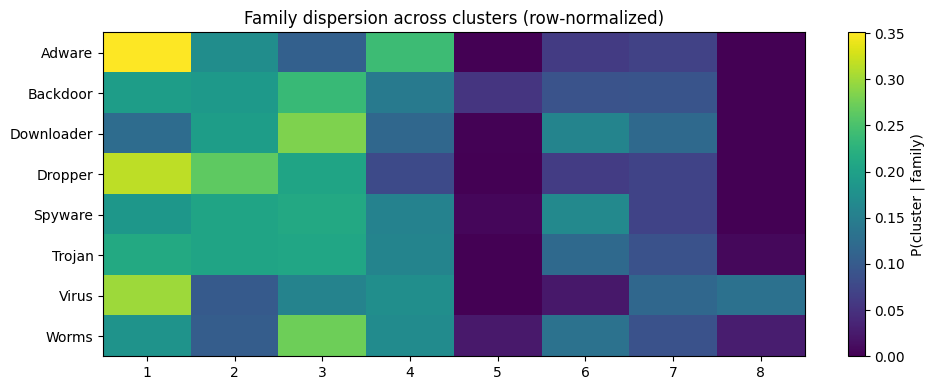

Global silhouette (from samples): 0.2185547679082349
Cluster 1: size=1582, mean=0.1104, median=0.1354, min=-0.4283, q25=-0.0014, q75=0.2458, max=0.4192
Cluster 2: size=1265, mean=0.4755, median=0.5168, min=-0.0827, q25=0.4101, q75=0.5682, max=0.6280
Cluster 3: size=1559, mean=0.0986, median=0.1354, min=-0.4696, q25=-0.0265, q75=0.2484, max=0.3866
Cluster 4: size=1052, mean=0.2737, median=0.3583, min=-0.3904, q25=0.1302, q75=0.4825, max=0.5252
Cluster 5: size=86, mean=0.3682, median=0.4371, min=-0.2204, q25=0.1966, q75=0.5831, max=0.6144
Cluster 6: size=740, mean=-0.0277, median=-0.0123, min=-0.4277, q25=-0.1325, q75=0.0836, max=0.2014
Cluster 7: size=654, mean=0.4567, median=0.4869, min=-0.0848, q25=0.3845, q75=0.5635, max=0.6594
Cluster 8: size=169, mean=0.1517, median=0.2111, min=-0.4467, q25=0.0193, q75=0.3068, max=0.3465
Macro cluster (largest): 1
Cluster  1 | size=1582 | dist_to_macro=    0.0000 | nearest= 3 (d=  1.4826)
Cluster  3 | size=1559 | dist_to_macro=    1.4826 | nearest=

In [118]:
print(f"\n=== Run 1: noise_rate=0.01 ===")

# no training involved, obfuscated sets used as validation
ARI_val, NMI_val, sil_score, dbi_score, val_labels_run, clusters_val_run = run_one_obfuscated_clustering_experiment( \
                                                                         tuned_models, family_names, family_to_all_obfuscated_sequences_01)
# cluster stats
cluster_stats(clusters_val_run, val_labels_run)

print(f"ARI: {ARI_val:.6f}, NMI: {NMI_val:.6f}, Silhouette score: {sil_score:.6f}, DB score: {dbi_score:.6f}")

In [119]:
# noise_rate=0.05
obfuscated_Xy_05 = json.load(open("obfuscated_sequences_point_05.json"))
obfuscated_X_int_05 = obfuscated_Xy_05["X_int"]
obfuscated_y_05 = obfuscated_Xy_05["y"]

In [120]:
# one shot extract all sequences belonging to each family
family_to_all_obfuscated_sequences_05 = {fam: [] for fam in family_names}
for seq, label in zip(obfuscated_X_int_05, obfuscated_y_05):
    if label in family_to_all_obfuscated_sequences_05:
        family_to_all_obfuscated_sequences_05[label].append(seq)

# sanity check
for fam in family_names:
    print(f"Family {fam:9s} : n = {len(family_to_all_obfuscated_sequences_05[fam])}")

Family Trojan    : n = 1001
Family Backdoor  : n = 1001
Family Downloader : n = 1001
Family Worms     : n = 1001
Family Virus     : n = 1001
Family Dropper   : n = 891
Family Spyware   : n = 832
Family Adware    : n = 379



=== Run 1: noise_rate=0.05 ===
   cluster  size majority_family  majority_count    purity  entropy_bits  \
0        3  1691      Downloader             281  0.166174      2.941038   
1        2  1689      Downloader             315  0.186501      2.887506   
2        1  1271         Dropper             195  0.153423      2.980552   
3        5   765           Virus             145  0.189542      2.918973   
4        8   751        Backdoor             153  0.203728      2.892937   
5        7   681         Spyware             153  0.224670      2.835077   
6        6   207           Virus             132  0.637681      1.198852   
7        4    52        Backdoor              27  0.519231      1.767842   

   num_families_present  
0                     8  
1                     8  
2                     8  
3                     8  
4                     8  
5                     8  
6                     4  
7                     5  
col_0              1         2         3         

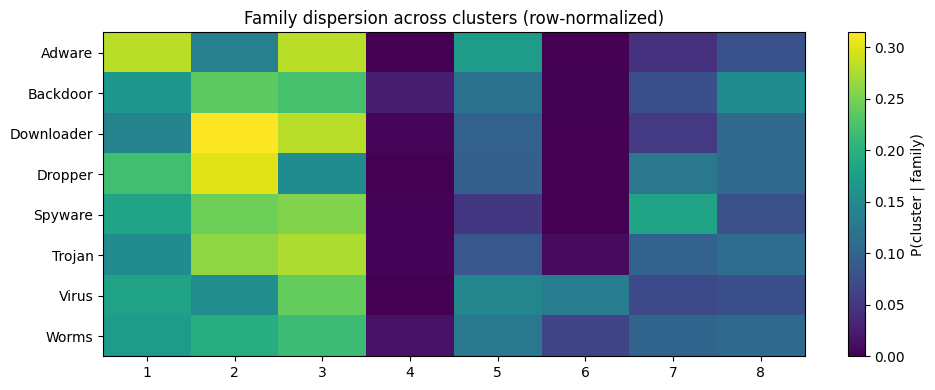

Global silhouette (from samples): 0.25989840217934657
Cluster 1: size=1271, mean=0.1641, median=0.1997, min=-0.3828, q25=0.0678, q75=0.2942, max=0.4338
Cluster 2: size=1689, mean=0.3805, median=0.4475, min=-0.2906, q25=0.2901, q75=0.5193, max=0.5674
Cluster 3: size=1691, mean=0.3995, median=0.4641, min=-0.1853, q25=0.2976, q75=0.5437, max=0.5809
Cluster 4: size=52, mean=0.4933, median=0.6214, min=-0.1642, q25=0.2623, q75=0.6551, max=0.6752
Cluster 5: size=765, mean=-0.0193, median=-0.0033, min=-0.4889, q25=-0.1066, q75=0.0900, max=0.2291
Cluster 6: size=207, mean=0.0176, median=0.0631, min=-0.3290, q25=-0.1322, q75=0.1982, max=0.2482
Cluster 7: size=681, mean=0.2254, median=0.2488, min=-0.3034, q25=0.1033, q75=0.3798, max=0.4995
Cluster 8: size=751, mean=0.2027, median=0.2349, min=-0.3162, q25=0.1084, q75=0.3289, max=0.4267
Macro cluster (largest): 3
Cluster  3 | size=1691 | dist_to_macro=    0.0000 | nearest= 8 (d=  1.2214)
Cluster  2 | size=1689 | dist_to_macro=    6.5594 | nearest= 

In [121]:
print(f"\n=== Run 1: noise_rate=0.05 ===")

# no training involved, obfuscated sets used as validation
ARI_val, NMI_val, sil_score, dbi_score, val_labels_run, clusters_val_run = run_one_obfuscated_clustering_experiment( \
                                                                         tuned_models, family_names, family_to_all_obfuscated_sequences_05)
# cluster stats
cluster_stats(clusters_val_run, val_labels_run)

print(f"ARI: {ARI_val:.6f}, NMI: {NMI_val:.6f}, Silhouette score: {sil_score:.6f}, DB score: {dbi_score:.6f}")

In [122]:
# noise_rate=0.1
obfuscated_Xy_1 = json.load(open("obfuscated_sequences_point_1.json"))
obfuscated_X_int_1 = obfuscated_Xy_1["X_int"]
obfuscated_y_1 = obfuscated_Xy_1["y"]

In [123]:
# one shot extract all sequences belonging to each family
family_to_all_obfuscated_sequences_1 = {fam: [] for fam in family_names}
for seq, label in zip(obfuscated_X_int_1, obfuscated_y_1):
    if label in family_to_all_obfuscated_sequences_1:
        family_to_all_obfuscated_sequences_1[label].append(seq)

# sanity check
for fam in family_names:
    print(f"Family {fam:9s} : n = {len(family_to_all_obfuscated_sequences_1[fam])}")

Family Trojan    : n = 1001
Family Backdoor  : n = 1001
Family Downloader : n = 1001
Family Worms     : n = 1001
Family Virus     : n = 1001
Family Dropper   : n = 891
Family Spyware   : n = 832
Family Adware    : n = 379



=== Run 1: noise_rate=0.1 ===
   cluster  size majority_family  majority_count    purity  entropy_bits  \
0        5  2313      Downloader             418  0.180718      2.943462   
1        2  1739          Trojan             301  0.173088      2.934821   
2        1  1211           Worms             204  0.168456      2.922258   
3        7   913         Dropper             163  0.178532      2.896162   
4        8   658           Virus             111  0.168693      2.887198   
5        4   118           Virus             115  0.974576      0.170895   
6        3   101           Virus              58  0.574257      1.256908   
7        6    54        Backdoor              28  0.518519      1.600120   

   num_families_present  
0                     8  
1                     8  
2                     8  
3                     8  
4                     8  
5                     2  
6                     3  
7                     4  
col_0              1         2         3         4

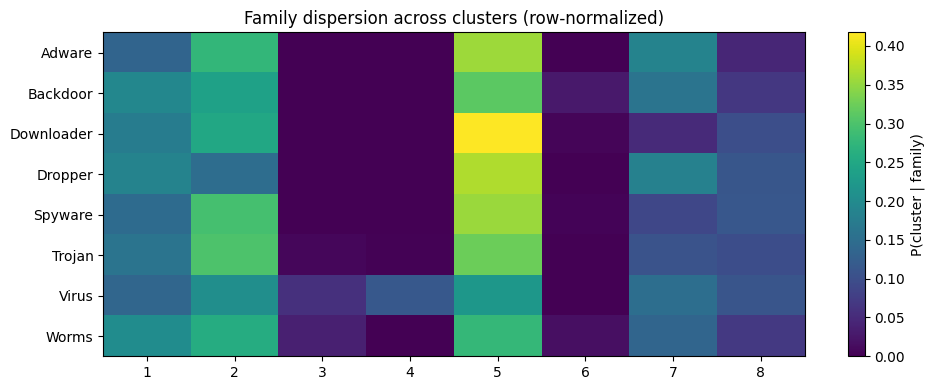

Global silhouette (from samples): 0.2875352233572901
Cluster 1: size=1211, mean=0.2658, median=0.2885, min=-0.4058, q25=0.1541, q75=0.4013, max=0.5082
Cluster 2: size=1739, mean=0.2452, median=0.2961, min=-0.4106, q25=0.1166, q75=0.4012, max=0.4510
Cluster 3: size=101, mean=0.4110, median=0.4008, min=-0.0842, q25=0.2538, q75=0.6138, max=0.6198
Cluster 4: size=118, mean=0.2761, median=0.3483, min=-0.4402, q25=0.2258, q75=0.4571, max=0.5189
Cluster 5: size=2313, mean=0.4280, median=0.5010, min=-0.2839, q25=0.3154, q75=0.5774, max=0.6212
Cluster 6: size=54, mean=0.4985, median=0.6163, min=-0.0855, q25=0.3062, q75=0.6673, max=0.6796
Cluster 7: size=913, mean=0.1227, median=0.1380, min=-0.2838, q25=0.0383, q75=0.2241, max=0.3649
Cluster 8: size=658, mean=0.1401, median=0.1537, min=-0.3011, q25=0.0357, q75=0.2593, max=0.3932
Macro cluster (largest): 5
Cluster  5 | size=2313 | dist_to_macro=    0.0000 | nearest= 7 (d=  1.8535)
Cluster  2 | size=1739 | dist_to_macro=    5.9807 | nearest= 1 (d=

In [124]:
print(f"\n=== Run 1: noise_rate=0.1 ===")

# no training involved, obfuscated sets used as validation
ARI_val, NMI_val, sil_score, dbi_score, val_labels_run, clusters_val_run = run_one_obfuscated_clustering_experiment( \
                                                                         tuned_models, family_names, family_to_all_obfuscated_sequences_1)
# cluster stats
cluster_stats(clusters_val_run, val_labels_run)

print(f"ARI: {ARI_val:.6f}, NMI: {NMI_val:.6f}, Silhouette score: {sil_score:.6f}, DB score: {dbi_score:.6f}")

#### Benchmark Clustering on whole of clean dataset

In [125]:
# one shot extract all sequences belonging to each family
family_to_all_clean_sequences = {fam: [] for fam in family_names}
for seq, label in zip(X_int, y):
    if label in family_to_all_clean_sequences:
        family_to_all_clean_sequences[label].append(seq)

# sanity check
for fam in family_names:
    print(f"Family {fam:9s} : n = {len(family_to_all_clean_sequences[fam])}")

Family Trojan    : n = 1001
Family Backdoor  : n = 1001
Family Downloader : n = 1001
Family Worms     : n = 1001
Family Virus     : n = 1001
Family Dropper   : n = 891
Family Spyware   : n = 832
Family Adware    : n = 379



=== Benchmark Run ===
   cluster  size majority_family  majority_count    purity  entropy_bits  \
0        2  2159      Downloader             460  0.213062      2.890795   
1        1  1549      Downloader             288  0.185926      2.890852   
2        7  1166         Dropper             214  0.183533      2.917683   
3        8  1103           Virus             220  0.199456      2.862182   
4        3   517          Trojan             137  0.264990      2.666934   
5        5   287           Virus             138  0.480836      1.346400   
6        4   209           Virus             202  0.966507      0.273323   
7        6   117        Backdoor              74  0.632479      1.440072   

   num_families_present  
0                     8  
1                     8  
2                     8  
3                     8  
4                     8  
5                     5  
6                     5  
7                     6  
col_0              1         2         3         4        

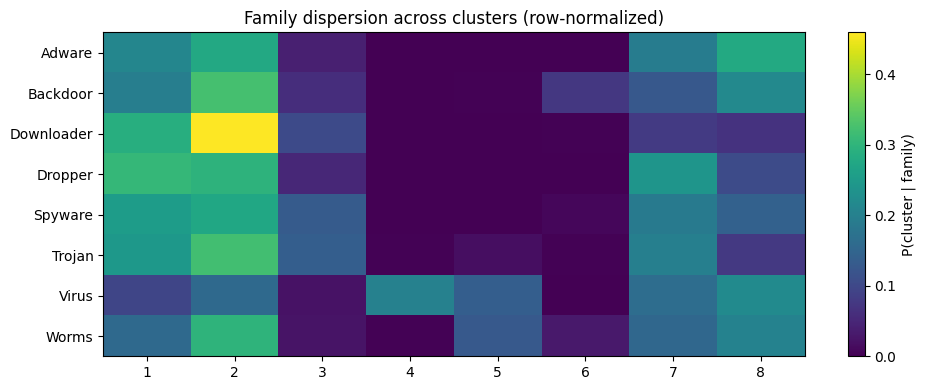

Global silhouette (from samples): 0.15439257941520623
Cluster 1: size=1549, mean=0.4753, median=0.5033, min=-0.0324, q25=0.4183, q75=0.5576, max=0.6197
Cluster 2: size=2159, mean=0.0264, median=0.0561, min=-0.5122, q25=-0.0784, q75=0.1533, max=0.3056
Cluster 3: size=517, mean=-0.0565, median=-0.0408, min=-0.4855, q25=-0.1444, q75=0.0447, max=0.1907
Cluster 4: size=209, mean=0.2792, median=0.3763, min=-0.3042, q25=0.1327, q75=0.4742, max=0.4986
Cluster 5: size=287, mean=0.2163, median=0.2331, min=-0.3667, q25=0.1079, q75=0.3981, max=0.4131
Cluster 6: size=117, mean=0.3997, median=0.4072, min=-0.2076, q25=0.3361, q75=0.5940, max=0.6107
Cluster 7: size=1166, mean=0.1571, median=0.1812, min=-0.3175, q25=0.0676, q75=0.2645, max=0.4007
Cluster 8: size=1103, mean=-0.0155, median=-0.0073, min=-0.3885, q25=-0.1236, q75=0.1087, max=0.2491
Macro cluster (largest): 2
Cluster  2 | size=2159 | dist_to_macro=    0.0000 | nearest= 1 (d=  1.0565)
Cluster  1 | size=1549 | dist_to_macro=    1.0565 | near

In [126]:
print(f"\n=== Benchmark Run ===")

# no training involved, clean benchmark dataset used as validation
ARI_val, NMI_val, sil_score, dbi_score, val_labels_run, clusters_val_run = run_one_obfuscated_clustering_experiment( \
                                                                         tuned_models, family_names, family_to_all_clean_sequences)
# cluster stats
cluster_stats(clusters_val_run, val_labels_run)

print(f"ARI: {ARI_val:.6f}, NMI: {NMI_val:.6f}, Silhouette score: {sil_score:.6f}, DB score: {dbi_score:.6f}")

While supervised classification achieved moderate accuracy, unsupervised clustering based on PST-derived likelihood embeddings revealed a fundamentally different structure. Rather than aligning with malware family labels, clusters were organized around shared behavioral patterns, with a dominant macro-cluster representing common execution behavior and several small, well-separated clusters capturing rare or specialized behaviors. Per-cluster silhouette scores and centroid distance analysis confirm that these clusters are geometrically coherent and well-separated, indicating meaningful behavioral grouping independent of taxonomy.

## UPDATED OBFUSCATED CLUSTERING (ignore above)

In [131]:
def run_new_clustering_experiment(
    tuned_models,
    family_names,
    family_to_sequences,
    num_clusters,
    scaler=None,            # if provided, use transform; else fit a new scaler
    fit_scaler=True,        # only used when scaler is None
    return_embeddings=False # to support distance-preservation analysis
):
    # build dataset
    val_seqs  = []
    val_labels = []
    for fam in family_names:
        for s in family_to_sequences[fam]:
            val_seqs.append(s)
            val_labels.append(fam)

    # embeddings (length-normalized LL)
    X_embed = []
    for seq in val_seqs:
        vec = likelihood_vector_len_norm(seq, tuned_models, family_names)
        X_embed.append(vec)
    X_embed = np.vstack(X_embed)

    # scaling (CRUCIAL: reuse clean scaler for obf robustness comparisons)
    if scaler is None:
        scaler = StandardScaler()
        Xz = scaler.fit_transform(X_embed) if fit_scaler else scaler.transform(X_embed)
    else:
        Xz = scaler.transform(X_embed)

    # clustering
    Z = linkage(Xz, method='ward')
    clusters = fcluster(Z, t=num_clusters, criterion='maxclust')

    # external validity vs family labels (taxonomy alignment)
    ARI_ext = adjusted_rand_score(val_labels, clusters)
    NMI_ext = normalized_mutual_info_score(val_labels, clusters)

    # internal metrics
    sil_score = silhouette_score(Xz, clusters, metric="euclidean")
    dbi_score = davies_bouldin_score(Xz, clusters)

    # ----- your existing reporting -----
    clusters_np = np.asarray(clusters)
    labels_np = np.asarray(val_labels)
    ct = pd.crosstab(labels_np, clusters_np)

    cluster_summary = cluster_purity_entropy(ct)
    print(cluster_summary)

    family_cluster_props = ct.div(ct.sum(axis=1), axis=0).fillna(0.0)
    print(family_cluster_props)

    plt.figure(figsize=(10, 4))
    plt.imshow(family_cluster_props.values, aspect='auto')
    plt.yticks(range(len(family_cluster_props.index)), family_cluster_props.index)
    plt.xticks(range(len(family_cluster_props.columns)), family_cluster_props.columns)
    plt.colorbar(label="P(cluster | family)")
    plt.title("Family dispersion across clusters (row-normalized)")
    plt.tight_layout()
    plt.show()

    global_sil, cluster_sil_stats = per_cluster_silhouette_stats(Xz, clusters)
    print("Global silhouette (from samples):", global_sil)
    for c in sorted(cluster_sil_stats):
        st = cluster_sil_stats[c]
        print(f"Cluster {c}: size={st['size']}, mean={st['mean']:.4f}, "
              f"median={st['median']:.4f}, min={st['min']:.4f}, q25={st['q25']:.4f}, "
              f"q75={st['q75']:.4f}, max={st['max']:.4f}")

    macro, rows = cluster_centroid_distances(Xz, clusters)
    print("Macro cluster (largest):", macro)
    for c, sz, dmacro, near, dnear in rows:
        print(f"Cluster {c:>2} | size={sz:>4} | dist_to_macro={dmacro:>10.4f} | nearest={near:>2} (d={dnear:>8.4f})")

    if return_embeddings:
        return ARI_ext, NMI_ext, sil_score, dbi_score, val_labels, clusters, scaler, X_embed, Xz
    return ARI_ext, NMI_ext, sil_score, dbi_score, val_labels, clusters, scaler

   cluster  size majority_family  majority_count    purity  entropy_bits  \
0        2  2159      Downloader             460  0.213062      2.890795   
1        1  1549      Downloader             288  0.185926      2.890852   
2        7  1166         Dropper             214  0.183533      2.917683   
3        8  1103           Virus             220  0.199456      2.862182   
4        3   517          Trojan             137  0.264990      2.666934   
5        5   287           Virus             138  0.480836      1.346400   
6        4   209           Virus             202  0.966507      0.273323   
7        6   117        Backdoor              74  0.632479      1.440072   

   num_families_present  
0                     8  
1                     8  
2                     8  
3                     8  
4                     8  
5                     5  
6                     5  
7                     6  
col_0              1         2         3         4         5         6  \
row_0  

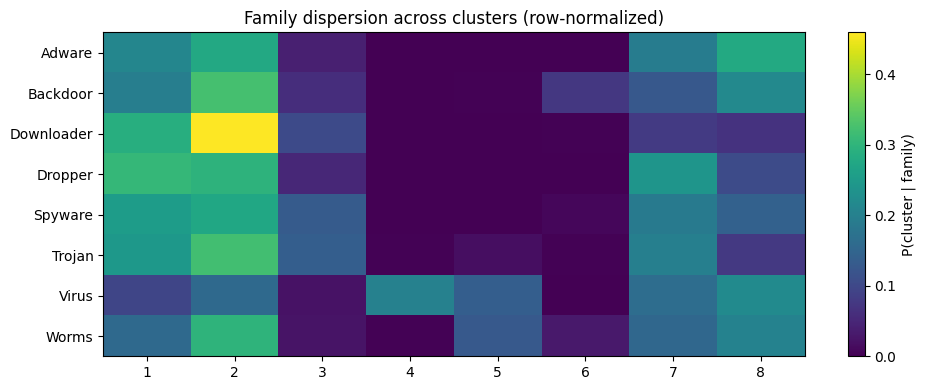

Global silhouette (from samples): 0.15439257941520623
Cluster 1: size=1549, mean=0.4753, median=0.5033, min=-0.0324, q25=0.4183, q75=0.5576, max=0.6197
Cluster 2: size=2159, mean=0.0264, median=0.0561, min=-0.5122, q25=-0.0784, q75=0.1533, max=0.3056
Cluster 3: size=517, mean=-0.0565, median=-0.0408, min=-0.4855, q25=-0.1444, q75=0.0447, max=0.1907
Cluster 4: size=209, mean=0.2792, median=0.3763, min=-0.3042, q25=0.1327, q75=0.4742, max=0.4986
Cluster 5: size=287, mean=0.2163, median=0.2331, min=-0.3667, q25=0.1079, q75=0.3981, max=0.4131
Cluster 6: size=117, mean=0.3997, median=0.4072, min=-0.2076, q25=0.3361, q75=0.5940, max=0.6107
Cluster 7: size=1166, mean=0.1571, median=0.1812, min=-0.3175, q25=0.0676, q75=0.2645, max=0.4007
Cluster 8: size=1103, mean=-0.0155, median=-0.0073, min=-0.3885, q25=-0.1236, q75=0.1087, max=0.2491
Macro cluster (largest): 2
Cluster  2 | size=2159 | dist_to_macro=    0.0000 | nearest= 1 (d=  1.0565)
Cluster  1 | size=1549 | dist_to_macro=    1.0565 | near

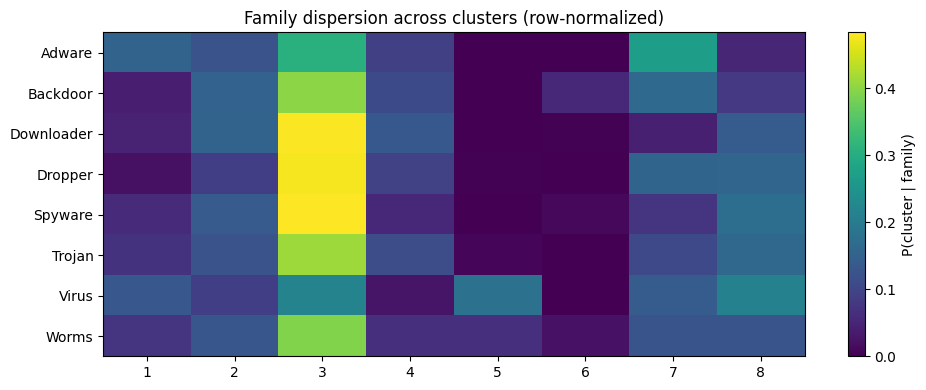

Global silhouette (from samples): 0.2747166545584495
Cluster 1: size=491, mean=0.4030, median=0.4271, min=-0.0443, q25=0.3359, q75=0.4956, max=0.5565
Cluster 2: size=892, mean=0.2855, median=0.3369, min=-0.4196, q25=0.1244, q75=0.4786, max=0.5723
Cluster 3: size=2844, mean=0.4053, median=0.4951, min=-0.3374, q25=0.2994, q75=0.5677, max=0.6120
Cluster 4: size=615, mean=0.1872, median=0.1794, min=-0.4237, q25=0.0899, q75=0.3146, max=0.4483
Cluster 5: size=262, mean=-0.0583, median=-0.0184, min=-0.4511, q25=-0.1846, q75=0.0961, max=0.2180
Cluster 6: size=89, mean=0.3525, median=0.4280, min=-0.1960, q25=0.1339, q75=0.5704, max=0.6046
Cluster 7: size=886, mean=0.1795, median=0.1899, min=-0.2091, q25=0.1153, q75=0.2748, max=0.3907
Cluster 8: size=1028, mean=0.0553, median=0.0678, min=-0.3689, q25=-0.0364, q75=0.1610, max=0.3058
Macro cluster (largest): 3
Cluster  3 | size=2844 | dist_to_macro=    0.0000 | nearest= 7 (d=  1.8886)
Cluster  8 | size=1028 | dist_to_macro=    3.3198 | nearest= 7 

In [132]:
# 1) Cluster CLEAN baseline (fit scaler here)
ARI_clean, NMI_clean, Sil_clean, DBI_clean, labels_clean, clusters_clean, clean_scaler, X_clean, Xz_clean = \
    run_new_clustering_experiment(
        tuned_models=tuned_models,
        family_names=family_names,
        family_to_sequences=family_to_all_clean_sequences,  # <-- your clean dict
        num_clusters=num_clusters,
        scaler=None,
        return_embeddings=True
    )

# 2) Cluster OBFUSCATED dataset (reuse the CLEAN scaler)
ARI_obf, NMI_obf, Sil_obf, DBI_obf, labels_obf, clusters_obf, _, X_obf, Xz_obf = \
    run_new_clustering_experiment(
        tuned_models=tuned_models,
        family_names=family_names,
        family_to_sequences=family_to_all_obfuscated_sequences_01,  # <-- your obf dict
        num_clusters=num_clusters,
        scaler=clean_scaler,             # <-- key change
        return_embeddings=True
    )

# 3) Partition stability (robustness) — compares clusters to clusters
ARI_partition = adjusted_rand_score(clusters_clean, clusters_obf)
NMI_partition = normalized_mutual_info_score(clusters_clean, clusters_obf)

print("noise=0.01")
print("External validity (clean): ARI=", ARI_clean, "NMI=", NMI_clean)
print("External validity (obf):   ARI=", ARI_obf,   "NMI=", NMI_obf)
print("Robustness (clean vs obf): ARI_partition=", ARI_partition, "NMI_partition=", NMI_partition)

In [133]:
from scipy.spatial.distance import pdist
from scipy.stats import pearsonr, spearmanr

d_clean = pdist(Xz_clean, metric="euclidean")
d_obf   = pdist(Xz_obf,   metric="euclidean")

pear = pearsonr(d_clean, d_obf)[0]
spear = spearmanr(d_clean, d_obf).correlation
stress = np.sum((d_obf - d_clean)**2) / np.sum(d_clean**2)

print("Distance preservation: Pearson r =", pear)
print("Distance preservation: Spearman rho =", spear)
print("Relative stress =", stress)

Distance preservation: Pearson r = 0.47598363318290504
Distance preservation: Spearman rho = 0.4463315418992086
Relative stress = 0.4526296811667049


   cluster  size majority_family  majority_count    purity  entropy_bits  \
0        1  2197      Downloader             349  0.158853      2.959170   
1        5  1701      Downloader             284  0.166961      2.942882   
2        6  1237        Backdoor             203  0.164107      2.929906   
3        3  1219        Backdoor             207  0.169811      2.917512   
4        8   483         Spyware             104  0.215321      2.760272   
5        7   154           Worms              80  0.519481      1.320330   
6        4    62           Virus              59  0.951613      0.323939   
7        2    54        Backdoor              36  0.666667      1.185986   

   num_families_present  
0                     8  
1                     8  
2                     8  
3                     8  
4                     8  
5                     4  
6                     3  
7                     4  
col_0              1         2         3         4         5         6  \
row_0  

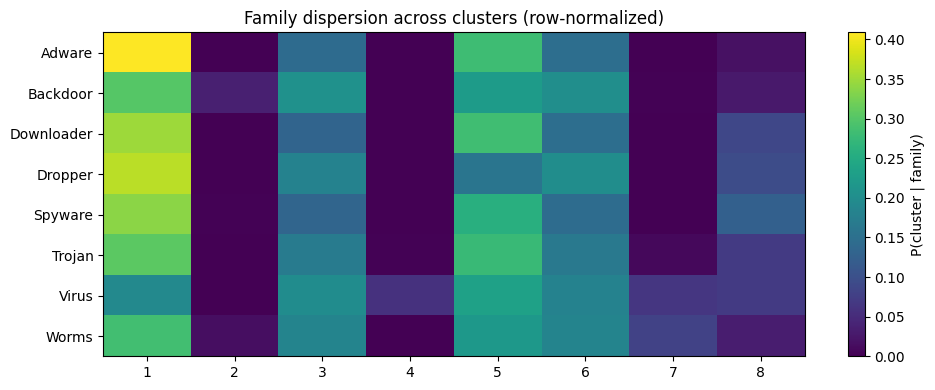

Global silhouette (from samples): 0.3474551307853348
Cluster 1: size=2197, mean=0.4774, median=0.5386, min=-0.2148, q25=0.3875, q75=0.6091, max=0.6513
Cluster 2: size=54, mean=0.5024, median=0.6063, min=-0.2507, q25=0.4086, q75=0.6639, max=0.6785
Cluster 3: size=1219, mean=0.1420, median=0.1718, min=-0.3908, q25=0.0437, q75=0.2649, max=0.4251
Cluster 4: size=62, mean=0.4104, median=0.4900, min=-0.3110, q25=0.3154, q75=0.5950, max=0.6011
Cluster 5: size=1701, mean=0.4754, median=0.5427, min=-0.2070, q25=0.3788, q75=0.6083, max=0.6380
Cluster 6: size=1237, mean=0.2666, median=0.2899, min=-0.3380, q25=0.1084, q75=0.4504, max=0.5587
Cluster 7: size=154, mean=0.2137, median=0.2631, min=-0.3823, q25=0.0828, q75=0.4096, max=0.4219
Cluster 8: size=483, mean=0.0487, median=0.0682, min=-0.3375, q25=-0.0357, q75=0.1446, max=0.2583
Macro cluster (largest): 1
Cluster  1 | size=2197 | dist_to_macro=    0.0000 | nearest= 3 (d=  1.8911)
Cluster  5 | size=1701 | dist_to_macro=    7.4280 | nearest= 6 (d

In [134]:
# 2) Cluster OBFUSCATED dataset 0.05 (reuse the CLEAN scaler)
ARI_obf, NMI_obf, Sil_obf, DBI_obf, labels_obf, clusters_obf, _, X_obf, Xz_obf = \
    run_new_clustering_experiment(
        tuned_models=tuned_models,
        family_names=family_names,
        family_to_sequences=family_to_all_obfuscated_sequences_05,  # <-- your obf dict
        num_clusters=num_clusters,
        scaler=clean_scaler,             # <-- key change
        return_embeddings=True
    )

# 3) Partition stability (robustness) — compares clusters to clusters
ARI_partition = adjusted_rand_score(clusters_clean, clusters_obf)
NMI_partition = normalized_mutual_info_score(clusters_clean, clusters_obf)

print("noise=0.05")
print("External validity (clean): ARI=", ARI_clean, "NMI=", NMI_clean)
print("External validity (obf):   ARI=", ARI_obf,   "NMI=", NMI_obf)
print("Robustness (clean vs obf): ARI_partition=", ARI_partition, "NMI_partition=", NMI_partition)

In [135]:
d_clean = pdist(Xz_clean, metric="euclidean")
d_obf   = pdist(Xz_obf,   metric="euclidean")

pear = pearsonr(d_clean, d_obf)[0]
spear = spearmanr(d_clean, d_obf).correlation
stress = np.sum((d_obf - d_clean)**2) / np.sum(d_clean**2)

print("Distance preservation: Pearson r =", pear)
print("Distance preservation: Spearman rho =", spear)
print("Relative stress =", stress)

Distance preservation: Pearson r = 0.2787745718322157
Distance preservation: Spearman rho = 0.22429108067497552
Relative stress = 0.5163654347160895


   cluster  size majority_family  majority_count    purity  entropy_bits  \
0        8  1824      Downloader             368  0.201754      2.926855   
1        2  1682      Downloader             271  0.161118      2.925376   
2        4  1569          Trojan             262  0.166985      2.945539   
3        7   902         Dropper             168  0.186253      2.904737   
4        6   824         Dropper             150  0.182039      2.945724   
5        1   128           Worms              64  0.500000      1.249014   
6        3   124           Virus             101  0.814516      0.934201   
7        5    54        Backdoor              28  0.518519      1.600120   

   num_families_present  
0                     8  
1                     8  
2                     8  
3                     8  
4                     8  
5                     3  
6                     5  
7                     4  
col_0              1         2         3         4         5         6  \
row_0  

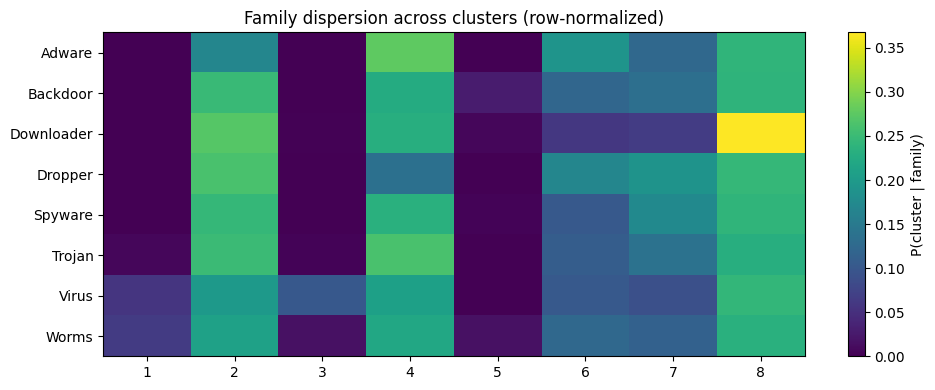

Global silhouette (from samples): 0.2415082106495187
Cluster 1: size=128, mean=0.2802, median=0.3027, min=-0.1736, q25=0.1501, q75=0.4870, max=0.4971
Cluster 2: size=1682, mean=0.0558, median=0.0679, min=-0.4499, q25=-0.1076, q75=0.2306, max=0.3935
Cluster 3: size=124, mean=0.1452, median=0.0999, min=-0.4086, q25=0.0180, q75=0.3155, max=0.4364
Cluster 4: size=1569, mean=0.5186, median=0.5576, min=-0.0309, q25=0.4583, q75=0.6182, max=0.6529
Cluster 5: size=54, mean=0.4884, median=0.6185, min=-0.1512, q25=0.2921, q75=0.6668, max=0.6797
Cluster 6: size=824, mean=0.1673, median=0.1852, min=-0.3707, q25=0.0809, q75=0.2762, max=0.4297
Cluster 7: size=902, mean=0.4413, median=0.4712, min=-0.0428, q25=0.3705, q75=0.5447, max=0.6008
Cluster 8: size=1824, mean=0.1057, median=0.1516, min=-0.4869, q25=-0.0280, q75=0.2707, max=0.4221
Macro cluster (largest): 8
Cluster  8 | size=1824 | dist_to_macro=    0.0000 | nearest= 7 (d=  1.1324)
Cluster  2 | size=1682 | dist_to_macro=    3.4841 | nearest= 4 (

In [136]:
# 2) Cluster OBFUSCATED dataset 0.1 (reuse the CLEAN scaler)
ARI_obf, NMI_obf, Sil_obf, DBI_obf, labels_obf, clusters_obf, _, X_obf, Xz_obf = \
    run_new_clustering_experiment(
        tuned_models=tuned_models,
        family_names=family_names,
        family_to_sequences=family_to_all_obfuscated_sequences_1,  # <-- your obf dict
        num_clusters=num_clusters,
        scaler=clean_scaler,             # <-- key change
        return_embeddings=True
    )

# 3) Partition stability (robustness) — compares clusters to clusters
ARI_partition = adjusted_rand_score(clusters_clean, clusters_obf)
NMI_partition = normalized_mutual_info_score(clusters_clean, clusters_obf)

print("noise=0.1")
print("External validity (clean): ARI=", ARI_clean, "NMI=", NMI_clean)
print("External validity (obf):   ARI=", ARI_obf,   "NMI=", NMI_obf)
print("Robustness (clean vs obf): ARI_partition=", ARI_partition, "NMI_partition=", NMI_partition)

In [137]:
d_clean = pdist(Xz_clean, metric="euclidean")
d_obf   = pdist(Xz_obf,   metric="euclidean")

pear = pearsonr(d_clean, d_obf)[0]
spear = spearmanr(d_clean, d_obf).correlation
stress = np.sum((d_obf - d_clean)**2) / np.sum(d_clean**2)

print("Distance preservation: Pearson r =", pear)
print("Distance preservation: Spearman rho =", spear)
print("Relative stress =", stress)

Distance preservation: Pearson r = 0.35915412992116486
Distance preservation: Spearman rho = 0.26712034811157515
Relative stress = 0.3449425652744786


   cluster  size majority_family  majority_count    purity  entropy_bits  \
0        1  2213      Downloader             417  0.188432      2.931208   
1        4  1899           Worms             290  0.152712      2.976784   
2        3  1510         Dropper             259  0.171523      2.903620   
3        6   845           Worms             161  0.190533      2.885417   
4        8   355           Virus             180  0.507042      2.164996   
5        2   131         Dropper              24  0.183206      2.914001   
6        5    80        Backdoor              49  0.612500      1.629444   
7        7    74           Virus              49  0.662162      1.597835   

   num_families_present  
0                     8  
1                     8  
2                     8  
3                     8  
4                     7  
5                     8  
6                     6  
7                     6  
col_0              1         2         3         4         5         6  \
row_0  

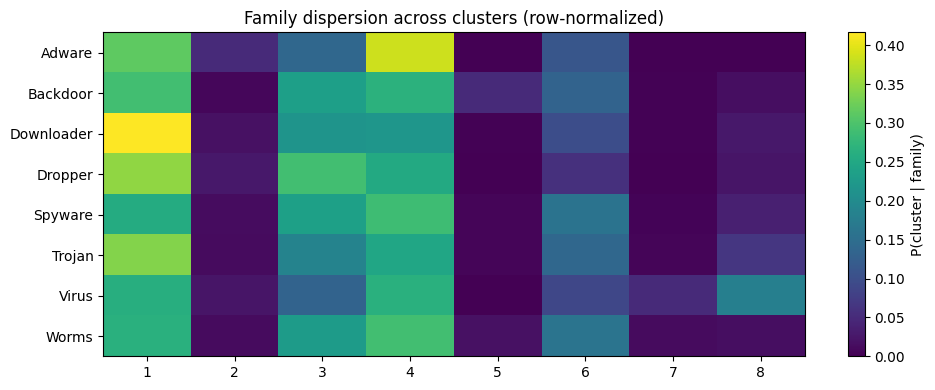

Global silhouette (from samples): 0.20285343560322772
Cluster 1: size=2213, mean=0.1250, median=0.1488, min=-0.3757, q25=-0.0027, q75=0.2648, max=0.4263
Cluster 2: size=131, mean=0.3993, median=0.4587, min=-0.0589, q25=0.3124, q75=0.5235, max=0.5793
Cluster 3: size=1510, mean=0.3560, median=0.4104, min=-0.2943, q25=0.2669, q75=0.4934, max=0.5652
Cluster 4: size=1899, mean=0.3484, median=0.4014, min=-0.2916, q25=0.2459, q75=0.4927, max=0.5544
Cluster 5: size=80, mean=0.3089, median=0.2999, min=-0.2016, q25=0.1656, q75=0.5186, max=0.5557
Cluster 6: size=845, mean=-0.1286, median=-0.1079, min=-0.5102, q25=-0.2758, q75=0.0248, max=0.1592
Cluster 7: size=74, mean=0.2982, median=0.3791, min=-0.1644, q25=0.1810, q75=0.4699, max=0.4816
Cluster 8: size=355, mean=-0.0692, median=-0.0458, min=-0.4690, q25=-0.1706, q75=0.0658, max=0.1586
Macro cluster (largest): 1
Cluster  1 | size=2213 | dist_to_macro=    0.0000 | nearest= 4 (d=  0.8578)
Cluster  4 | size=1899 | dist_to_macro=    0.8578 | nearest

In [142]:
# 2) Cluster OBFUSCATED dataset 0.2 (reuse the CLEAN scaler)
ARI_obf, NMI_obf, Sil_obf, DBI_obf, labels_obf, clusters_obf, _, X_obf, Xz_obf = \
    run_new_clustering_experiment(
        tuned_models=tuned_models,
        family_names=family_names,
        family_to_sequences=family_to_all_obfuscated_sequences,  # <-- your obf dict
        num_clusters=num_clusters,
        scaler=clean_scaler,             # <-- key change
        return_embeddings=True
    )

# 3) Partition stability (robustness) — compares clusters to clusters
ARI_partition = adjusted_rand_score(clusters_clean, clusters_obf)
NMI_partition = normalized_mutual_info_score(clusters_clean, clusters_obf)

print("noise=0.2")
print("External validity (clean): ARI=", ARI_clean, "NMI=", NMI_clean)
print("External validity (obf):   ARI=", ARI_obf,   "NMI=", NMI_obf)
print("Robustness (clean vs obf): ARI_partition=", ARI_partition, "NMI_partition=", NMI_partition)

In [143]:
d_clean = pdist(Xz_clean, metric="euclidean")
d_obf   = pdist(Xz_obf,   metric="euclidean")

pear = pearsonr(d_clean, d_obf)[0]
spear = spearmanr(d_clean, d_obf).correlation
stress = np.sum((d_obf - d_clean)**2) / np.sum(d_clean**2)

print("Distance preservation: Pearson r =", pear)
print("Distance preservation: Spearman rho =", spear)
print("Relative stress =", stress)

Distance preservation: Pearson r = 0.6501597735450213
Distance preservation: Spearman rho = 0.5701153150111009
Relative stress = 0.3239686723047554
